# IMPORT LIBRARY

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (compiled): {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Compute capability
cc = torch.cuda.get_device_capability(0)
print(f"Compute Capability: {cc[0]}.{cc[1]}")

# Test đơn giản xem CUDA có chạy được không
x = torch.randn(2, 2).cuda()
y = x @ x
print(f"CUDA test OK: {y.shape}")

PyTorch version: 2.11.0+cu128
CUDA version (compiled): 12.8
cuDNN version: 91900
GPU: NVIDIA GeForce RTX 5060 Ti
Compute Capability: 12.0
CUDA test OK: torch.Size([2, 2])


In [2]:
import random
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # Đặt biến môi trường để giúp debug lỗi CUDA
os.environ["TORCH_USE_CUDA_DSA"] = "True"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
import numpy as np
import torch
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm

import nibabel as nib
import matplotlib.pyplot as plt
import wandb

from scipy.ndimage import zoom as nd_zoom
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold  # Bắt buộc để chia K-Foldimport wandb

from torch.optim import Adam

import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_id = torch.cuda.current_device()
device_name = torch.cuda.get_device_name(device_id)

allocated = torch.cuda.memory_allocated(device_id) / (1024**2)
# Bộ nhớ tối đa từng bị chiếm dụng (Max Allocated)
max_allocated = torch.cuda.max_memory_allocated(device_id) / (1024**2)
# Bộ nhớ đang được cache bởi PyTorch giữ lại (Reserved/Cached)
reserved = torch.cuda.memory_reserved(device_id) / (1024**2)

print(f"🖥️  Thiết bị: {device_name} (ID: {device_id})")
print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"device: {device}")
print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Graphics card: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

🖥️  Thiết bị: NVIDIA GeForce RTX 5060 Ti (ID: 0)
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB
device: cuda
torch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900
Graphics card: NVIDIA GeForce RTX 5060 Ti
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# SQUEEZE EXCITATION

In [4]:
class SqueezeExcitation(nn.Module):
    """Squeeze and Excitation (SE) Attention Block"""
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, d, h, w = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

# PARALLEL CONVOLUTION

In [5]:
class ParallelConvolutionBlock(nn.Module):
    """
    PC Block theo paper Fig.2:
    shared 3x3x3 embed → 3 parallel paths (1x1x1, 3x3x3, 5x5x5) → maxpool → concat
    Không có BatchNorm (paper không đề cập norm trong PC block)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.shared_conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv1 = nn.Conv3d(out_channels, out_channels, kernel_size=1, padding=0)
        self.conv3 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv3d(out_channels, out_channels, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward_with_skip(self, x):
        """Trả về (x_shared, pc_out) để LATUPNet dùng x_shared làm skip connection."""
        x_shared = self.relu(self.shared_conv(x))          # (B, out_ch, H, W, D) — full res
        path1 = self.pool(self.relu(self.conv1(x_shared)))
        path2 = self.pool(self.relu(self.conv3(x_shared)))
        path3 = self.pool(self.relu(self.conv5(x_shared)))
        pc_out = torch.cat([path1, path2, path3], dim=1)   # (B, out_ch*3, H/2, W/2, D/2)
        return x_shared, pc_out

    def forward(self, x):
        _, pc_out = self.forward_with_skip(x)
        return pc_out

# ENCODER

In [6]:
class EncoderBlock(nn.Module):
    """
    Theo Table 1 paper: SE → Conv → InstanceNorm → Conv → Dropout → MaxPool
    SE đặt TRƯỚC hai conv, không phải sau.
    """
    def __init__(self, in_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.se = SqueezeExcitation(in_channels) if use_se else nn.Identity()

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        # Paper không đề cập InstanceNorm sau conv2 trong encoder, nhưng Table 1 có
        self.norm2 = nn.InstanceNorm3d(out_channels, affine=True)

        self.dropout = nn.Dropout3d(dropout_rate)
        self.pool    = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.se(x)                            # SE trước
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        skip = x                                   # skip trước pooling
        x = self.pool(x)
        return x, skip

# DECODER

In [7]:
class DecoderBlock(nn.Module):
    """
    Theo Table 1: Upsample → Conv → InstanceNorm → SE → Concat(skip) → Conv
    SE đặt GIỮA hai conv (sau conv1, trước concat+conv2) — đúng paper Section 3.
    """
    def __init__(self, in_channels, skip_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()

        self.conv2   = nn.Conv3d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.norm2   = nn.InstanceNorm3d(out_channels, affine=True)
        self.dropout = nn.Dropout3d(dropout_rate)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.se(x)
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        return x

# LATUP-NET MODEL

In [8]:
class LATUPNet(nn.Module):
    """
    LATUP-Net theo đúng Table 1 paper:
    - Input: (B, 3, 128, 128, 128)  — T2, T1ce, FLAIR (không có T1, Section 4.1)
    - 3 encoder blocks (PC + enc2 + enc3)
    - 3 decoder blocks (dec3 + dec2 + dec1)
    - Output: (B, 4, 128, 128, 128)
    """
    def __init__(self, in_channels=3, num_classes=3, use_se=True, dropout_rate=0.2):
        super().__init__()

        # PC block: (B,3,128,128,128) → (B,96,64,64,64)
        self.pc_block = ParallelConvolutionBlock(in_channels, 32)

        # Encoder 2: (B,96,64,64,64) → (B,64,32,32,32), skip1: (B,64,64,64,64)
        self.enc2 = EncoderBlock(96, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Encoder 3: (B,64,32,32,32) → (B,128,16,16,16), skip2: (B,128,32,32,32)
        self.enc3 = EncoderBlock(64, 128, use_se=use_se, dropout_rate=dropout_rate)

        # Bottleneck SE (Table 1: SE Layer_3 at bottleneck)
        self.bottleneck_se = SqueezeExcitation(128) if use_se else nn.Identity()

        # Decoder 3: (B,128,16,16,16) + skip2(B,128,32,32,32) → (B,128,32,32,32)
        self.dec3 = DecoderBlock(128, 128, 128, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 2: (B,128,32,32,32) + skip1(B,64,64,64,64) — wait, skip1 là 64ch
        # Theo Table 1: dec2 concat shape (64,64,64,128) → out 64
        self.dec2 = DecoderBlock(128, 64, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 1: (B,64,64,64,64) upsample → (B,128,128,128) + skip_pc
        # skip từ PC block output (B,96,64,64,64) — nhưng paper dùng skip từ PC trước pool
        # Table 1 dec1_concat shape: (128,128,128,64) → paper dùng skip của PC embedded (32ch trước pool)
        # dec1: conv1 64→32, concat skip_pc(32ch per path? không) 
        # Theo Table 1 chính xác: dec1_conv1 input=64→32, concat→64ch, conv2 64→32
        self.dec1 = DecoderBlock(64, 32, 32, use_se=False, dropout_rate=dropout_rate)

        # Final 1x1x1 conv → softmax (paper Section 3)
        self.final_conv = nn.Conv3d(32, num_classes, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.InstanceNorm3d):
                if m.weight is not None:
                    nn.init.constant_(m.weight, 1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # PC block — lưu skip từ shared conv (trước pool) theo Table 1 dec1_concat
        # Table 1: dec1_concat input (128,128,128,32) → skip là output shared_conv (32ch, full res)
        # Tuy nhiên paper Fig.1 cho thấy skip từ PC là toàn bộ PC output trước pool
        # Theo Table 1 dec1_concat shape=(128,128,128,64): 32(dec1_conv1 out) + 32(skip_pc shared) = 64 ✓
        x_shared = self.pc_block.relu(self.pc_block.shared_conv(x))  # (B,32,128,128,128)
        skip_pc  = x_shared

        x = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv1(x_shared)))
        p2 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv3(x_shared)))
        p3 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv5(x_shared)))
        x = torch.cat([x, p2, p3], dim=1)       # (B,96,64,64,64)

        x, skip2 = self.enc2(x)                  # x:(B,64,32,32,32), skip2:(B,64,64,64,64)
        x, skip3 = self.enc3(x)                  # x:(B,128,16,16,16), skip3:(B,128,32,32,32)

        x = self.bottleneck_se(x)                # (B,128,16,16,16)

        x = self.dec3(x, skip3)                  # (B,128,32,32,32)
        x = self.dec2(x, skip2)                  # (B,64,64,64,64)
        x = self.dec1(x, skip_pc)                # (B,32,128,128,128)

        return self.final_conv(x)                 # (B,4,128,128,128) — full res, no extra upsample needed

# DICE LOSS

In [9]:
class WeightedDiceLoss(nn.Module):
    """
    WDL theo đúng Eq.(3) và (4) trong paper:
    Tính DSL riêng cho NCR/NET (ch1), ED (ch2), ET (ch4→ch3 trong output)
    Không gộp region trước khi tính — weight theo region importance sau.
    
    w_WT=1.64, w_TC=2.55, w_ET=3.40  (ENet formula, paper Section 4.3)
    WDL = (w_WT+w_TC+w_ET)*DSL_ET + (w_WT+w_TC)*DSL_NCR + w_WT*DSL_ED
    """
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon
        self.w_wt = 4.51
        self.w_tc = 5.37
        self.w_et = 6.12

    def _dice_loss(self, pred, target):
        pred_f   = pred.contiguous().view(-1)
        target_f = target.contiguous().view(-1)
        
        intersection = (pred_f * target_f).sum()
        union = pred_f.sum() + target_f.sum()
        
        return 1.0 - (2. * intersection + self.epsilon) / (union + self.epsilon)
    
    def forward(self, pred, target):
        """
        pred:   (B, 4, H, W, D) — logits, channels: [BG, NCR/NET, ED, ET]
        target: (B, H, W, D)    — labels {0,1,2,4} (BraTS convention)
        """
        # 1. Chuyển đổi logits thành xác suất bằng Softmax theo chiều Channels
        pred_soft = F.softmax(pred, dim=1)

        p_ncr = pred_soft[:, 1]
        p_ed  = pred_soft[:, 2]
        p_et  = pred_soft[:, 3]

        # 2. Tạo các mặt nạ nhãn đơn lẻ (One-hot) từ Ground-truth gốc
        t_ncr = (target == 1).float()
        t_ed  = (target == 2).float()
        t_et  = (target == 4).float()

        # =========================================================================
        # Bước 3: ĐỊNH NGHĨA LẠI CÁC VÙNG LÂM SÀNG (Bản chất cấu trúc khối u BraTS)
        # =========================================================================
        # Vùng Toàn bộ u (WT) = Hoại tử (NCR) + Phù nề (ED) + U tăng cường (ET)
        pred_wt   = p_ncr + p_ed + p_et
        target_wt = t_ncr + t_ed + t_et

        # Vùng Lõi u (TC) = Hoại tử (NCR) + U tăng cường (ET)
        pred_tc   = p_ncr + p_et
        target_tc = t_ncr + t_et

        # Vùng U tăng cường (ET) = Chỉ gồm ET
        pred_et   = p_et
        target_et = t_et

        # =========================================================================
        # Bước 4: TÍNH DICE LOSS CHO TỪNG VÙNG ĐỘC LẬP
        # =========================================================================
        dsl_wt = self._dice_loss(pred_wt, target_wt)
        dsl_tc = self._dice_loss(pred_tc, target_tc)
        dsl_et = self._dice_loss(pred_et, target_et)

        # =========================================================================
        # Bước 5: TỔNG HỢP LOSS THEO TRỌNG SỐ ĐÃ SAN PHẲNG (Dạng Trung bình Trọng số)
        # =========================================================================
        # Tránh việc cộng dồn tích lũy (w_wt + w_tc + w_et) đè nặng lên một lớp đơn lẻ
        wdl = (self.w_wt * dsl_wt + self.w_tc * dsl_tc + self.w_et * dsl_et) / (self.w_wt + self.w_tc + self.w_et)

        return wdl

In [10]:
# Create model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("LATUP-Net Model Summary")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Parameter count: {trainable_params / 1e6:.2f}M")
print(f"Expected: ~3.07M parameters (as reported in paper)")

# Test forward pass
batch_size = 1
depth, height, width = 128, 128, 128
channels = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

x = torch.randn(batch_size, channels, depth, height, width).to(device)

print(f"\nInput shape: {x.shape}")

with torch.no_grad():
    output = model(x)

print(f"Output shape: {output.shape}")

# Verify channel flow
print(f"\nChannel flow verification:")
print(f"  Input: {channels} channels")
print(f"  After PC block: 96 channels")
print(f"  After Enc1: 64 channels (skip: 64)")
print(f"  After Enc2: 128 channels (skip: 128)")
print(f"  After Bottleneck: 128 channels")
print(f"  After Dec2: 64 channels")
print(f"  After Dec1: 32 channels")
print(f"  Final output: 4 channels (BG, NCR/NET, ED, ET)")

# Test loss function
target = torch.randint(0, 5, (batch_size, depth, height, width)).to(device)
target[target == 3] = 4  # Ensure BraTS label convention

criterion = WeightedDiceLoss()
loss = criterion(output, target)
print(f"\nWeighted Dice Loss: {loss.item():.4f}")

print("\n" + "=" * 60)
print("Model structure:")
print("=" * 60)
print(model)

LATUP-Net Model Summary
Total parameters: 2,988,388
Trainable parameters: 2,988,388
Parameter count: 2.99M
Expected: ~3.07M parameters (as reported in paper)

Input shape: torch.Size([1, 3, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])

Channel flow verification:
  Input: 3 channels
  After PC block: 96 channels
  After Enc1: 64 channels (skip: 64)
  After Enc2: 128 channels (skip: 128)
  After Bottleneck: 128 channels
  After Dec2: 64 channels
  After Dec1: 32 channels
  Final output: 4 channels (BG, NCR/NET, ED, ET)

Weighted Dice Loss: 0.5013

Model structure:
LATUPNet(
  (pc_block): ParallelConvolutionBlock(
    (shared_conv): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (relu): LeakyReLU(negative_slope=0.1, inplace=True)
    (conv1): Conv3d(32, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (conv3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (conv5): Conv3d(32, 32, kernel_size=(5, 5, 5), strid

# PRE-PROCESSING DATA

In [11]:
def find_volume(patient_dir, patient_id, modality):
    """Find a valid .nii or .nii.gz file for one BraTS modality, handling inconsistent naming."""
    patient_dir = Path(patient_dir)
    
    # 1. Định nghĩa các mẫu từ khóa tìm kiếm cho từng modality (bất kể viết hoa/thường)
    modality_lower = modality.lower()
    
    if modality_lower == "seg":
        # Tìm các file chứa "seg" hoặc "segm" (để xử lý case bệnh nhân 355)
        search_patterns = ["*seg*.nii", "*seg*.nii.gz", "*Segm*.nii", "*Segm*.nii.gz"]
    else:
        # Với t1, t1ce, t2, flair: tìm file chứa đúng từ khóa đó (ví dụ: *_flair.nii)
        search_patterns = [f"*{modality_lower}.nii", f"*{modality_lower}.nii.gz"]

    # 2. Quét qua các mẫu để tìm file thực tế trong thư mục
    for pattern in search_patterns:
        # Chạy glob không phân biệt hoa thường (trên Windows/Linux tùy cấu hình, dùng rglob/glob)
        hits = list(patient_dir.glob(pattern))
        
        # Nếu không thấy, thử tìm phiên bản viết hoa chữ cái đầu (như Flair, T1ce...)
        if not hits:
            hits = list(patient_dir.glob(pattern.capitalize()))
            
        for path in hits:
            # Kiểm tra xem file có hợp lệ (tồn tại và không trống) không
            if path.exists() and path.stat().st_size > 0:
                return path

    # 3. Nếu không tìm thấy bằng glob, quay lại fallback cơ bản (để hiển thị danh sách đã thử)
    candidates = [
        patient_dir / f"{patient_id}_{modality}.nii",
        patient_dir / f"{patient_id}_{modality}.nii.gz",
    ]
    tried = [str(p) for p in candidates] + [str(patient_dir / p) for p in search_patterns]
    
    zip_candidates = [patient_dir / f"{patient_id}_{modality}.nii.zip"]
    zip_hits = [p for p in zip_candidates if p.exists()]
    zip_note = ""
    if zip_hits:
        zip_note = "\nFound .zip files. Extract them before loading NIfTI data:\n" + "\n".join(map(str, zip_hits))

    raise FileNotFoundError(
        f"Could not find modality '{modality}' for {patient_id} in {patient_dir}. Tried patterns:\n"
        + "\n".join(tried)
        + zip_note
    )


def load_volume(patient_dir, patient_id, modality):
    path = find_volume(patient_dir, patient_id, modality)
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    # print(f"Loaded {modality:5s}: {path.name} | shape={data.shape} | dtype={data.dtype}")
    return data, img

Đang hiển thị lát cắt thứ 77 của bệnh nhân BraTS20_Training_001
Kích thước khối ảnh: (240, 240, 155)


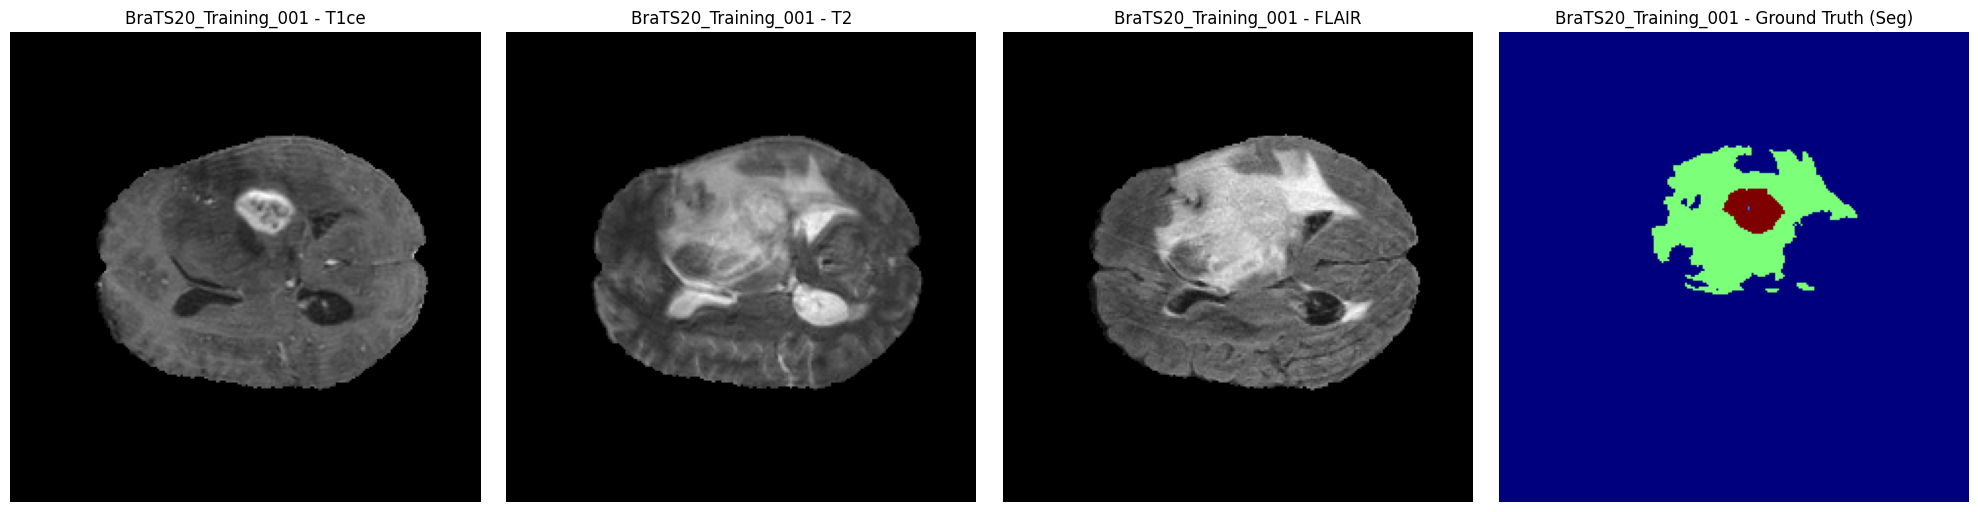

In [12]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name

modalities = ["t1ce", "t2", "flair", "seg"]
volumes = {}
slice_idx = None  # Mặc định sẽ lấy lát cắt chính giữa

# 1. Load toàn bộ các chuỗi xung và mask giải phẫu
for mod in modalities:
    try:
        volumes[mod], _ = load_volume(PATIENT_DIR, PATIENT_ID, mod)
    except Exception as e:
        print(f"Lỗi khi load chuỗi {mod}: {e}")

# 2. Xác định lát cắt để hiển thị (Mặc định lấy lát cắt chính giữa khối ảnh)
# Ảnh BraTS thường có shape (H, W, D) ví dụ (240, 240, 155) -> lấy tâm theo chiều dọc D
if slice_idx is None:
    slice_idx = volumes["flair"].shape[2] // 2

print(f"Đang hiển thị lát cắt thứ {slice_idx} của bệnh nhân {PATIENT_ID}")
print(f"Kích thước khối ảnh: {volumes['flair'].shape}")

# 3. Khởi tạo biểu đồ Matplotlib (1 hàng, 4 cột)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Chuỗi 1: T1ce
axes[0].imshow(volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1ce")
axes[0].axis("off")

# Chuỗi 2: T2
axes[1].imshow(volumes["t2"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T2")
axes[1].axis("off")

# Chuỗi 3: FLAIR
axes[2].imshow(volumes["flair"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - FLAIR")
axes[2].axis("off")

# Chuỗi 4: Segmentation Mask (Dùng cmap màu khác để nổi bật vùng u)
# BraTS có các nhãn: 0 (Nền), 1 (NCR/NET), 2 (ED), 4 (ET)
axes[3].imshow(volumes["seg"][:, :, slice_idx], cmap="jet")
axes[3].set_title(f"{PATIENT_ID} - Ground Truth (Seg)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [13]:
def resample_volume(volume, original_spacing, target_spacing=(1,1,1), order=1):
    zoom_factors = [o/t for o,t in zip(original_spacing, target_spacing)]
    return nd_zoom(volume, zoom_factors, order=order)

In [14]:
# Hàm bổ trợ cắt ảnh lấy tâm (Center Crop hoặc Pad nếu thiếu)
def crop_or_pad_3d(volume, target_shape=(128, 128, 128)):
    current_shape = volume.shape
    new_volume = np.zeros(target_shape, dtype=volume.dtype)
    
    # Tính toán chỉ số để cắt hoặc chèn cho từng chiều
    slices_src = []
    slices_dst = []
    
    for c, t in zip(current_shape, target_shape):
        if c >= t:
            # Nếu ảnh lớn hơn target -> Cắt lấy tâm
            start = (c - t) // 2
            slices_src.append(slice(start, start + t))
            slices_dst.append(slice(0, t))
        else:
            # Nếu ảnh nhỏ hơn target -> Chèn vào giữa (Padding)
            start = (t - c) // 2
            slices_src.append(slice(0, c))
            slices_dst.append(slice(start, start + c))
            
    new_volume[tuple(slices_dst)] = volume[tuple(slices_src)]
    return new_volume

Unique labels in original seg: [0. 1. 2. 4.]

--- Tiến hành Resample từ Spacing (np.float32(1.0), np.float32(1.0), np.float32(1.0)) về (1, 1, 1) ---
Resampled t1    shape: (240, 240, 155)
Resampled t1ce  shape: (240, 240, 155)
Resampled t2    shape: (240, 240, 155)
Resampled flair shape: (240, 240, 155)
Resampled seg   shape: (240, 240, 155)
Unique labels sau resample: [0 1 2 4]
Label 0: 8716021 voxels
Label 1: 15443 voxels
Label 2: 168794 voxels
Label 3: 0 voxels
Label 4: 27742 voxels
Final t1    shape after crop/pad: (128, 128, 128)
Final t1ce  shape after crop/pad: (128, 128, 128)
Final t2    shape after crop/pad: (128, 128, 128)
Final flair shape after crop/pad: (128, 128, 128)
Final seg   shape after crop/pad: (128, 128, 128)


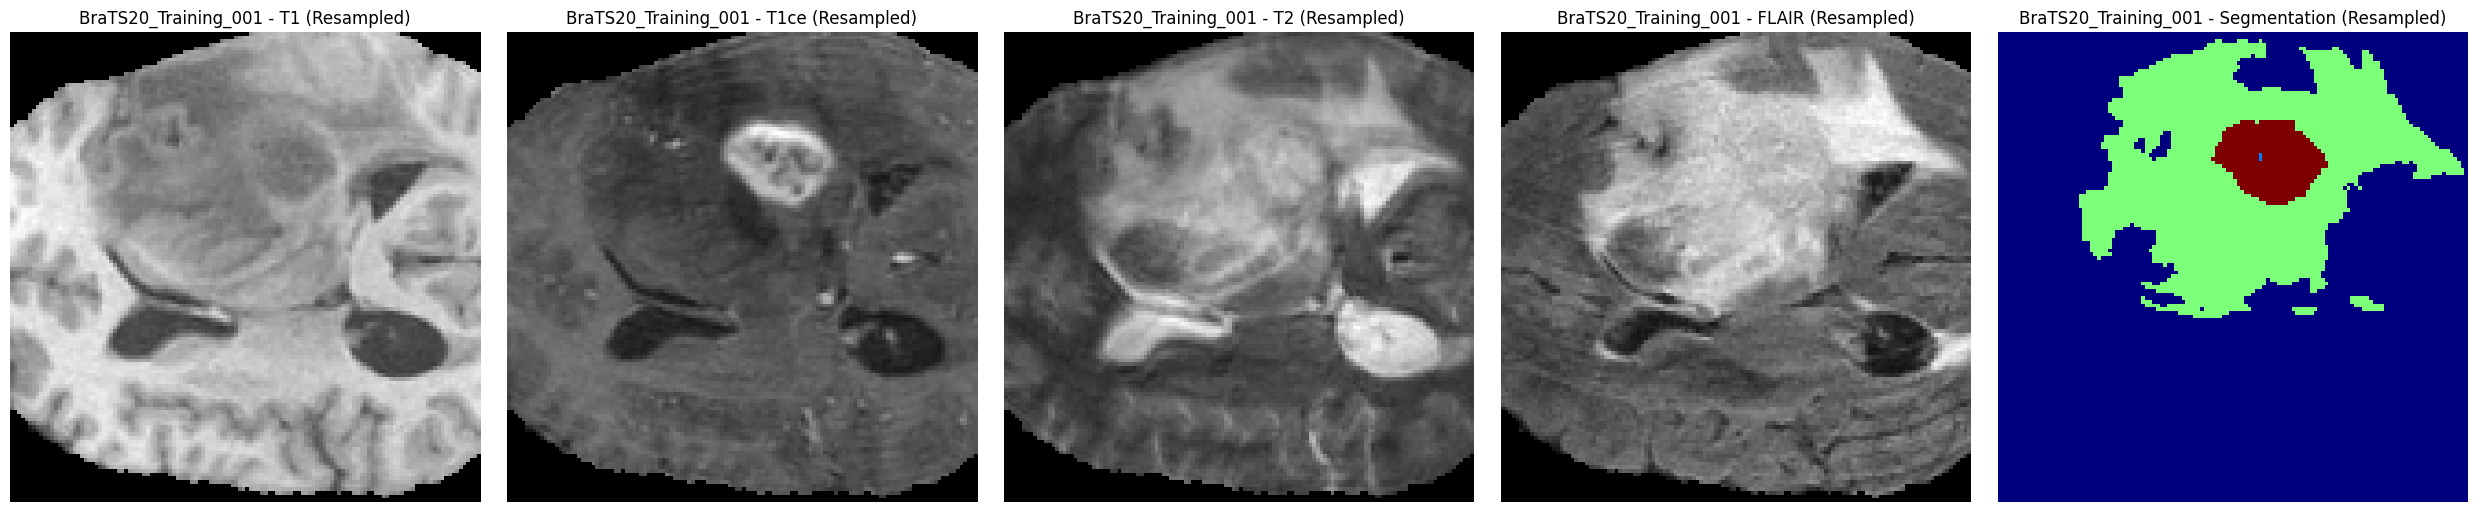

In [15]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name
MODALITIES = ["t1", "t1ce", "t2", "flair"]

# 1. Load dữ liệu gốc
volumes = {}
nifti_imgs = {}
for modality in MODALITIES:
    volumes[modality], nifti_imgs[modality] = load_volume(PATIENT_DIR, PATIENT_ID, modality)

seg, seg_img = load_volume(PATIENT_DIR, PATIENT_ID, "seg")
print(f"Unique labels in original seg: {np.unique(seg)}")
seg = seg.astype(np.uint8)

# 2. Lấy thông tin Spacing (Voxel size) gốc
# BraTS thường có spacing sẵn là (1, 1, 1), nhưng code này giúp xử lý cho mọi bộ dữ liệu khác
original_spacing = seg_img.header.get_zooms()[:3] 
TARGET_SPACING = (1, 1, 1)

print(f"\n--- Tiến hành Resample từ Spacing {original_spacing} về {TARGET_SPACING} ---")

# 3. Tiến hành Resample ảnh nhiễu/ảnh cường độ (t1, t2, flair...)
# Sử dụng order=1 (Bilinear) hoặc order=3 (Cubic) cho ảnh cấu trúc
resampled_volumes = {}
for modality in MODALITIES:
    resampled_volumes[modality] = resample_volume(
        volume=volumes[modality], 
        original_spacing=original_spacing, 
        target_spacing=TARGET_SPACING,
        order=1 
    )
    print(f"Resampled {modality:5s} shape: {resampled_volumes[modality].shape}")

# 4. Tiến hành Resample cho file Segmentation (seg)
# ĐẶC BIỆT LƯU Ý: Phải dùng order=0 (Nearest Neighbor) cho nhãn kết quả (0, 1, 2, 4...)
resampled_seg = resample_volume(
    volume=seg, 
    original_spacing=original_spacing, 
    target_spacing=TARGET_SPACING,
    order=0  # Bắt buộc bằng 0 để giữ nguyên giá trị các nhãn (Label) dạng số nguyên
)
print(f"Resampled seg   shape: {resampled_seg.shape}")
print("Unique labels sau resample:", np.unique(resampled_seg))
for i in range(5):
    print(f"Label {i}: {(resampled_seg == i).sum()} voxels")

# 5. Cắt hoặc Pad ảnh về kích thước (128, 128, 128) theo yêu cầu của model
final_volumes = {}
for modality in MODALITIES:
    final_volumes[modality] = crop_or_pad_3d(resampled_volumes[modality], target_shape=(128, 128, 128))
    print(f"Final {modality:5s} shape after crop/pad: {final_volumes[modality].shape}")
final_seg = crop_or_pad_3d(resampled_seg, target_shape=(128, 128, 128))
print(f"Final seg   shape after crop/pad: {final_seg.shape}")

# 6. Kiểm tra lại các lát cắt sau khi resample và crop/pad
slice_idx = final_volumes["flair"].shape[2] // 2
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(final_volumes["t1"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1 (Resampled)")
axes[0].axis("off")
axes[1].imshow(final_volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T1ce (Resampled)")
axes[1].axis("off")
axes[2].imshow(final_volumes["t2"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - T2 (Resampled)")
axes[2].axis("off")
axes[3].imshow(final_volumes["flair"][:, :, slice_idx], cmap="gray")
axes[3].set_title(f"{PATIENT_ID} - FLAIR (Resampled)")
axes[3].axis("off")
axes[4].imshow(final_seg[:, :, slice_idx], cmap="jet")
axes[4].set_title(f"{PATIENT_ID} - Segmentation (Resampled)")
axes[4].axis("off")
plt.tight_layout()
plt.show()

In [16]:
def calculate_brats_weights(dataset_dir, target_shape=(128, 128, 128)):
    """
    Quét qua tập dữ liệu BraTS để tính toán trọng số WT, TC, ET 
    dựa trên các hàm tiền xử lý cắt tâm/resize của bạn.
    """
    total_wt_voxels = 0
    total_tc_voxels = 0
    total_et_voxels = 0
    total_voxels = 0
    
    # Tìm tất cả các file nhãn segmentation (_seg.nii hoặc _seg.nii.gz)
    seg_files = []
    for root, dirs, files in os.walk(dataset_dir):
        for f in files:
            if '_seg.nii' in f:
                seg_files.append(os.path.join(root, f))
                
    print(f"🔍 Tìm thấy {len(seg_files)} file nhãn để tính toán...")
    
    for file_path in tqdm(seg_files, desc="Đang quét dữ liệu"):
        seg_img = nib.load(file_path).get_fdata()
        
        # --- ĐỌC LOGIC TỪ CODE TIỀN XỬ LÝ CỦA BẠN ---
        # Giả sử bạn đã đưa volume nhãn về 128x128x128 giống lúc train:
        # (Nếu tính trên ảnh gốc, bạn chỉ cần bỏ qua bước resize/crop)
        
        # BraTS Convention gốc: 
        # Label 1: Necrotic/Non-enhancing tumor
        # Label 2: Peritumoral edema
        # Label 4: GD-enhancing tumor
        
        # 1. Định nghĩa các vùng dựa trên tổ hợp nhãn
        wt_mask = (seg_img == 1) | (seg_img == 2) | (seg_img == 4)  # Toàn bộ u
        tc_mask = (seg_img == 1) | (seg_img == 4)                  # Lõi u
        et_mask = (seg_img == 4)                                  # U bắt thuốc
        
        total_wt_voxels += np.sum(wt_mask)
        total_tc_voxels += np.sum(tc_mask)
        total_et_voxels += np.sum(et_mask)
        total_voxels += seg_img.size

    # 2. Tính tần suất xuất hiện (Probability)
    p_wt = total_wt_voxels / total_voxels
    p_tc = total_tc_voxels / total_voxels
    p_et = total_et_voxels / total_voxels
    
    # 3. Áp dụng công thức làm mịn Logarithmic Inverse 
    # Công thức này rất phổ biến để ra được dải trọng số từ 1.0 đến 4.0
    w_wt = np.log(1 + (1 / (p_wt + 1e-6)))
    w_tc = np.log(1 + (1 / (p_tc + 1e-6)))
    w_et = np.log(1 + (1 / (p_et + 1e-6)))
    
    # Chuẩn hóa để trọng số nhỏ nhất (của WT) bắt đầu quanh mức mong muốn của paper
    # Hoặc sử dụng trực tiếp tỷ lệ nghịch có căn bậc: (1 / p)**0.25
    
    print("\n📊 Kết quả trọng số tính toán được:")
    print(f"self.w_wt = {w_wt:.2f}")
    print(f"self.w_tc = {w_tc:.2f}")
    print(f"self.w_et = {w_et:.2f}")
    
    return w_wt, w_tc, w_et

In [17]:
dataset_path = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
calculate_brats_weights(dataset_path)

🔍 Tìm thấy 368 file nhãn để tính toán...


Đang quét dữ liệu: 100%|██████████| 368/368 [00:28<00:00, 12.73it/s]


📊 Kết quả trọng số tính toán được:
self.w_wt = 4.51
self.w_tc = 5.37
self.w_et = 6.12


(np.float64(4.508359791715112),
 np.float64(5.37139502749082),
 np.float64(6.123806197971883))

# DATASET & DATALOADER

In [18]:
from Brats_Dataset.BratsSet import BraTSDataset3D

In [19]:
# =========================================================================
# 1. CẤU HÌNH THÔNG SỐ K-FOLD CHUNG
# =========================================================================
NUM_FOLDS = 5
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# 🛑 QUAN TRỌNG: Ép kiểu danh sách thư mục sang Numpy Array để cắt chỉ mục (index slicing)
train_patient_dirs = np.array([p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()])

# Khởi tạo bộ chia KFold từ Sklearn
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

print(f"📦 Tổng số bệnh nhân tìm thấy: {len(train_patient_dirs)}")
print(f"🔄 Đã cấu hình bộ chia {NUM_FOLDS}-Fold Cross Validation.\n")

# =========================================================================
# 2. VÒNG LẶP QUA TỪNG FOLD (MÔ PHỎNG HOẶC TÍCH HỢP VÀO TRAINING LOOP)
# =========================================================================
for fold, (train_idx, val_idx) in enumerate(kf.split(train_patient_dirs)):
    print(f"{'='*60}")
    print(f"🚀 [FOLD {fold + 1}/{NUM_FOLDS}] THIẾT LẬP DATALOADER")
    print(f"{'='*60}")
    
    # Chia tập dữ liệu dựa trên index của Fold hiện tại
    train_ds = train_patient_dirs[train_idx].tolist()
    val_ds = train_patient_dirs[val_idx].tolist()
    
    print(f"Số lượng bệnh nhân trong tập huấn luyện (Train): {len(train_ds)}")
    print(f"Số lượng bệnh nhân trong tập kiểm thử (Val)   : {len(val_ds)}")
    
    # Khởi tạo dataset thành phẩm riêng cho từng Fold
    train_brats_dataset = BraTSDataset3D(
        patient_dirs=train_ds,
        target_spacing=(1, 1, 1),
        target_size=(128, 128, 128)
    )
    val_brats_dataset = BraTSDataset3D(
        patient_dirs=val_ds,
        target_spacing=(1, 1, 1),
        target_size=(128, 128, 128)
    )
    
    # Tích hợp vào DataLoader của PyTorch cho Fold hiện tại
    train_loader = DataLoader(
        dataset=train_brats_dataset,
        batch_size=2,            # Giữ nguyên batch_size=2 của bạn (Lưu ý VRAM khi chạy 3D)
        shuffle=True,
        num_workers=2,           
        persistent_workers=True  
    )
    val_loader = DataLoader(
        dataset=val_brats_dataset,
        batch_size=2,
        shuffle=False,
        num_workers=2,
        persistent_workers=True  
    )
    
    # =====================================================================
    # CHẠY THỬ NGHIỆM ĐỂ KIỂM TRA ĐẦU RA (TEST CHECK TRÊN FOLD 1)
    # =====================================================================
    if fold == 0:
        print("\n--- 🔍 Đang test thử lấy 1 mẫu từ Dataset của Fold 1 ---")
        img_tensor, mask_tensor, p_id = train_brats_dataset[0]
        print(f"Bệnh nhân lấy thử: {p_id}")
        print(f"Kích thước Image Tensor: {img_tensor.shape} | Dtype: {img_tensor.dtype}")
        print(f"Kích thước Mask Tensor : {mask_tensor.shape} | Dtype: {mask_tensor.dtype}")
        print(f"Các class có trong mask: {torch.unique(mask_tensor)}")
        
        print("\n--- 🔍 Đang test thử lấy 1 batch dữ liệu đầu tiên của Fold 1 ---")
        for batch_idx, (batch_images, batch_masks, batch_ids) in enumerate(train_loader):
            print(f"Batch index: {batch_idx}")
            print(f"Batch Images shape: {batch_images.shape}") # Expect: (2, 3/4, 128, 128, 128)
            print(f"Batch Masks shape : {batch_masks.shape}")  # Expect: (2, 128, 128, 128)
            print(f"Danh sách bệnh nhân trong batch: {batch_ids}")
            break # Chỉ chạy thử 1 batch duy nhất để kiểm tra cấu trúc
            
    print(f"\n✅ Đã thiết lập xong DataLoader cho Fold {fold + 1}.\n")

📦 Tổng số bệnh nhân tìm thấy: 369
🔄 Đã cấu hình bộ chia 5-Fold Cross Validation.

🚀 [FOLD 1/5] THIẾT LẬP DATALOADER
Số lượng bệnh nhân trong tập huấn luyện (Train): 295
Số lượng bệnh nhân trong tập kiểm thử (Val)   : 74
Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

--- 🔍 Đang test thử lấy 1 mẫu từ Dataset của Fold 1 ---
Bệnh nhân lấy thử: BraTS20_Training_002
Kích thước Image Tensor: torch.Size([3, 128, 128, 128]) | Dtype: torch.float32
Kích thước Mask Tensor : torch.Size([128, 128, 128]) | Dtype: torch.int64
Các class có trong mask: tensor([0, 1, 2, 4])

--- 🔍 Đang test thử lấy 1 batch dữ liệu đầu tiên của Fold 1 ---
Batch index: 0
Batch Images shape: torch.Size([2, 3, 128, 128, 128])
Batch Masks shape : torch.Size([2, 128, 128, 128])
Danh sách bệnh nhân trong batch: ('BraTS20_Training_124', 'BraTS20_Training_160')

✅ Đã thiết lập xong DataLoader cho Fold 1.

🚀 [FOLD 2/5] THIẾT LẬP DATALOADER
Số lượng bệnh nhân trong tập huấn luy

In [20]:
train_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_003'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_004'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_005'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_006')]

In [21]:
val_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_014'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_021'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_022'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_035')]

In [22]:
def get_param_groups(model, weight_decay=0.02):
    l2_modules = ['enc3', 'dec3']
    
    l2_params = []
    no_l2_params = []
    
    for name, param in model.named_parameters():
        if any(m in name for m in l2_modules):
            l2_params.append(param)
        else:
            no_l2_params.append(param)
    
    return [
        {'params': no_l2_params, 'weight_decay': 0.0},
        {'params': l2_params,    'weight_decay': weight_decay},
    ]

In [23]:
# Khởi tạo model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)
# Khởi tạo optimizer 
optimizer = Adam(
    get_param_groups(model, weight_decay=0.02),
    lr=1e-4,
    betas=(0.9, 0.999)
)
# Khởi tạo loss function    
criterion = WeightedDiceLoss()

# COMPUTE EVALUATION METRICS

In [24]:
def get_region_masks(pred_np, true_np):
    """
    Trả về dict binary masks cho WT, TC, ET.
    pred_np : (H,W,D) values {0,1,2,3}   (channel index)
    true_np : (H,W,D) values {0,1,2,4}   (BraTS label)
    """
    regions = {
        # WT = NCR(1) + ED(2) + ET(3/4)
        "WT": {
            "pred": np.isin(pred_np, [1, 2, 3]),
            "true": np.isin(true_np, [1, 2, 4]),
        },
        # TC = NCR(1) + ET(3/4)
        "TC": {
            "pred": np.isin(pred_np, [1, 3]),
            "true": np.isin(true_np, [1, 4]),
        },
        # ET only
        "ET": {
            "pred": pred_np == 3,
            "true": true_np == 4,
        },
    }
    return regions

In [25]:
def dice_score(pred_bin, true_bin, eps=1e-5):
    inter = np.sum(pred_bin & true_bin)
    union = np.sum(pred_bin) + np.sum(true_bin)
    if union == 0:
        return 1.0  # cả hai đều rỗng → hoàn hảo
    return (2.0 * inter + eps) / (union + eps)
 
 
def iou_score(pred_bin, true_bin, eps=1e-5):
    inter = np.sum(pred_bin & true_bin)
    union = np.sum(pred_bin | true_bin)
    if union == 0:
        return 1.0
    return (inter + eps) / (union + eps)
 
 
def recall_score(pred_bin, true_bin, eps=1e-5):
    """Sensitivity / TPR"""
    tp = np.sum(pred_bin & true_bin)
    fn = np.sum(~pred_bin & true_bin)
    if (tp + fn) == 0:
        return 1.0
    return (tp + eps) / (tp + fn + eps)
 
 
def f1_score_seg(pred_bin, true_bin, eps=1e-5):
    """F1 = Dice (chúng đồng nhất với nhau trong segmentation)"""
    return dice_score(pred_bin, true_bin, eps)
 
 
def hausdorff95(pred_bin, true_bin, spacing=(1.0, 1.0, 1.0)):
    """
    HD95 — khoảng cách Hausdorff phân vị 95.
    Trả về 0.0 nếu một trong hai mask rỗng (trường hợp đặc biệt).
    """
    if not pred_bin.any() or not true_bin.any():
        return 0.0
 
    # Distance transform tính khoảng cách từ biên (EDT trên ~mask cho ra dist đến mask)
    dist_pred_to_true = distance_transform_edt(~true_bin, sampling=spacing)
    dist_true_to_pred = distance_transform_edt(~pred_bin, sampling=spacing)
 
    # Lấy khoảng cách tại các điểm trên biên của mask kia
    d1 = dist_pred_to_true[pred_bin]
    d2 = dist_true_to_pred[true_bin]
 
    hd95 = max(np.percentile(d1, 95), np.percentile(d2, 95))
    return float(hd95)
 
 
def assd(pred_bin, true_bin, spacing=(1.0, 1.0, 1.0)):
    """
    ASSD — Average Symmetric Surface Distance.
    Trả về 0.0 nếu một trong hai mask rỗng.
    """
    if not pred_bin.any() or not true_bin.any():
        return 0.0
 
    dist_pred_to_true = distance_transform_edt(~true_bin, sampling=spacing)
    dist_true_to_pred = distance_transform_edt(~pred_bin, sampling=spacing)
 
    d1 = dist_pred_to_true[pred_bin]
    d2 = dist_true_to_pred[true_bin]
 
    return float((np.mean(d1) + np.mean(d2)) / 2.0)

In [26]:
def compute_metrics(pred_np, true_np, spacing=(1.0, 1.0, 1.0)):
    """
    Tính toàn bộ metrics cho 1 ca bệnh.
    
    Args:
        pred_np : (H,W,D) numpy array, values {0,1,2,3}
        true_np : (H,W,D) numpy array, values {0,1,2,4}
        spacing : voxel spacing sau resampling (mặc định 1mm isotropic)
    
    Returns:
        dict với keys: DSC_WT, DSC_TC, DSC_ET,
                       HD95_WT, HD95_TC, HD95_ET,
                       IoU_WT, IoU_TC, IoU_ET,
                       Recall_WT, Recall_TC, Recall_ET,
                       F1_WT, F1_TC, F1_ET,
                       ASSD_WT, ASSD_TC, ASSD_ET
    """
    regions = get_region_masks(pred_np, true_np)
    results = {}
 
    for region, masks in regions.items():
        p = masks["pred"]
        t = masks["true"]
        results[f"DSC_{region}"]    = dice_score(p, t)
        results[f"HD95_{region}"]   = hausdorff95(p, t, spacing)
        results[f"IoU_{region}"]    = iou_score(p, t)
        results[f"Recall_{region}"] = recall_score(p, t)
        results[f"F1_{region}"]     = f1_score_seg(p, t)
        results[f"ASSD_{region}"]   = assd(p, t, spacing)
 
    return results

def compute_batch_dice_fast(pred_np, true_np):
    """
    Tính nhanh Dice cho WT, TC, ET từ nhãn {0,1,2,3/4} mà không tính HD95/ASSD.
    pred_np, true_np: mảng numpy 3D (H, W, D)
    """
    # Định nghĩa các vùng theo chuẩn BraTS
    # WT (Whole Tumor): Tất cả các class trừ background (1 + 2 + 3/4)
    p_wt, t_wt = (pred_np > 0), (true_np > 0)
    # TC (Tumor Core): Class 1 + 3/4 (hoặc tùy thuộc vào cách mapping của get_region_masks)
    # Giả định thông thường: 1 (necrotic), 3/4 (enhancing)
    p_tc, t_tc = np.isin(pred_np, [1, 3]), np.isin(true_np, [1, 4]) 
    # ET (Enhancing Tumor): Class 3 hoặc 4
    p_et, t_et = (pred_np == 3), (true_np == 4)

    def dice(p, t):
        union = np.sum(p) + np.sum(t)
        if union == 0: return 1.0
        return (2.0 * np.sum(p & t)) / union

    return {
        "WT": dice(p_wt, t_wt),
        "TC": dice(p_tc, t_tc),
        "ET": dice(p_et, t_et)
    }
 
 
def average_metrics(metrics_list):
    """Trung bình metrics qua nhiều ca bệnh."""
    if not metrics_list:
        return {}
    keys = metrics_list[0].keys()
    return {k: float(np.mean([m[k] for m in metrics_list])) for k in keys}

In [27]:
def compute_gflops(model, input_size=(1, 3, 128, 128, 128), device="cuda"):
    """
    Tính GFLOPs dùng thop (pip install thop).
    Trả về (macs_G, params_M).
    """
    try:
        from thop import profile as thop_profile
 
        dummy = torch.randn(*input_size).to(device)
        model_cpu = model.to(device)
        macs, params = thop_profile(model_cpu, inputs=(dummy,), verbose=False)
        gflops = macs / 1e9  # MACs → GFLOPs (1 MAC ≈ 2 FLOPs, nhưng thường báo GMACs)
        params_m = params / 1e6
        print(f"GFLOPs: {gflops:.2f} G | Params: {params_m:.2f} M")
        return gflops, params_m
    except ImportError:
        print("Chưa cài thop. Chạy: pip install thop")
        return None, None

In [28]:
def measure_inference_time(model, dataloader, device, n_warmup=3):
    """
    Đo thời gian inference trung bình mỗi ca bệnh (ms/case).
    
    Args:
        n_warmup: số batch bỏ qua để GPU warm up trước khi đo
    
    Returns:
        avg_time_ms: thời gian trung bình ms/case
    """
    model.eval()
    times = []
 
    with torch.no_grad():
        for i, (images, masks, patient_ids) in enumerate(dataloader):
            images = images.to(device)
            batch_size = images.shape[0]
 
            # GPU warm-up: không tính vào kết quả
            if i < n_warmup:
                _ = model(images)
                torch.cuda.synchronize()
                continue
 
            # Đo thời gian chính xác bằng CUDA event
            start_event = torch.cuda.Event(enable_timing=True)
            end_event   = torch.cuda.Event(enable_timing=True)
 
            start_event.record()
            _ = model(images)
            end_event.record()
 
            torch.cuda.synchronize()
            elapsed_ms = start_event.elapsed_time(end_event)  # ms cho cả batch
 
            # Chia cho batch size để được ms/case
            times.extend([elapsed_ms / batch_size] * batch_size)
 
    avg_time_ms = float(np.mean(times)) if times else 0.0
    print(f"Inference time: {avg_time_ms:.2f} ms/case")
    return avg_time_ms

# TRAINING MODEL

In [29]:
def generate_final_report(metrics_list):
    """Tính toán và in ra định dạng Mean ± Std chuẩn kết quả nghiên cứu."""
    if not metrics_list: 
        return {}
    
    keys = metrics_list[0].keys()
    report_summary = {}
    
    for k in keys:
        raw_values = [m[k] for m in metrics_list]
        report_summary[f"{k}_mean"] = np.mean(raw_values)
        report_summary[f"{k}_std"] = np.std(raw_values)
        
    # Xác định xem DSC có cần scale lên % không (nếu output dạng 0.0 -> 1.0)
    scale = 100.0 if report_summary["DSC_WT_mean"] <= 1.0 else 1.0
    
    print("\n📊 " + "═"*20 + " FINAL REPORT: MEAN ± STD " + "═"*20)
    print(f" ▪️ DSC WT (%)  : {report_summary['DSC_WT_mean']*scale:.2f} ± {report_summary['DSC_WT_std']*scale:.2f}")
    print(f" ▪️ DSC TC (%)  : {report_summary['DSC_TC_mean']*scale:.2f} ± {report_summary['DSC_TC_std']*scale:.2f}")
    print(f" ▪️ DSC ET (%)  : {report_summary['DSC_ET_mean']*scale:.2f} ± {report_summary['DSC_ET_std']*scale:.2f}")
    print(f" ──────────────────────────────────────────────────")
    print(f" ▪️ HD95 WT (mm): {report_summary['HD95_WT_mean']:.2f} ± {report_summary['HD95_WT_std']:.2f}")
    print(f" ▪️ HD95 TC (mm): {report_summary['HD95_TC_mean']:.2f} ± {report_summary['HD95_TC_std']:.2f}")
    print(f" ▪️ HD95 ET (mm): {report_summary['HD95_ET_mean']:.2f} ± {report_summary['HD95_ET_std']:.2f}")
    print("═"*66 + "\n")
    
    return report_summary

In [30]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, epoch=None, log_wandb=True):
    model.train()
    epoch_loss = 0.0
    
    # Khởi tạo biến tích lũy để tính trung bình epoch
    epoch_dice = {"WT": 0.0, "TC": 0.0, "ET": 0.0}

    for batch_idx, (images, masks, patient_ids) in tqdm(
        enumerate(dataloader), total=len(dataloader), desc="Training", unit="batch", leave=False
    ):
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # --- TÍNH DICE CHO BATCH ĐANG TRAIN ---
        preds_np = torch.argmax(outputs, dim=1).cpu().numpy()
        masks_np = masks.cpu().numpy()
        
        # Vì batch_size=1, lấy phần tử đầu tiên [0]
        batch_dice = compute_batch_dice_fast(preds_np[0], masks_np[0])
        
        for k in epoch_dice.keys():
            epoch_dice[k] += batch_dice[k]

        # Log batch-level loss và dice
        if log_wandb:
            wandb.log({
                "train/batch_loss": loss.item(),
                "train/batch_dice_WT": batch_dice["WT"],
                "train/batch_dice_TC": batch_dice["TC"],
                "train/batch_dice_ET": batch_dice["ET"]
            })

        if (batch_idx + 1) % 50 == 0:
            print(f'  Batch {batch_idx+1}/{len(dataloader)} | Loss: {loss.item():.4f} | Dice WT: {batch_dice["WT"]:.4f} | Dice TC: {batch_dice["TC"]:.4f} | Dice ET: {batch_dice["ET"]:.4f}')

    num_batches = len(dataloader)
    avg_loss = epoch_loss / num_batches
    
    print(f"Train Loss: {avg_loss:.4f}")
    print(f"Train DSC WT/TC/ET: {epoch_dice['WT']/num_batches:.4f} / {epoch_dice['TC']/num_batches:.4f} / {epoch_dice['ET']/num_batches:.4f}")

    if log_wandb:
        log_dict = {
            "train/epoch_loss": avg_loss,
            "train/epoch_dice_WT": epoch_dice["WT"] / num_batches,
            "train/epoch_dice_TC": epoch_dice["TC"] / num_batches,
            "train/epoch_dice_ET": epoch_dice["ET"] / num_batches,
        }
        if epoch is not None:
            log_dict["epoch"] = epoch
        wandb.log(log_dict)

    return avg_loss

In [31]:
def evaluate(model, dataloader, criterion, device, epoch=None, log_wandb=True):
    model.eval()
    eval_loss = 0.0
    all_metrics = []
    
    with torch.no_grad():
        for batch_idx, (images, masks, patient_ids) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch", leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            eval_loss += loss.item()

            preds_np = torch.argmax(outputs, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()

            # Tính toán toàn bộ metrics cho ca này (bao gồm cả HD95, ASSD nếu là tập Val cuối)
            # Do batch_size = 1 nên dùng lặp index 0
            m = compute_metrics(preds_np[0], masks_np[0], spacing=(1.0, 1.0, 1.0))
            all_metrics.append(m)

            # --- LOG CHI TIẾT VALIDATION CHO TỪNG BATCH ---
            if log_wandb:
                wandb.log({
                    "val/batch_loss": loss.item(),
                    "val/batch_dice_WT": m["DSC_WT"],
                    "val/batch_dice_TC": m["DSC_TC"],
                    "val/batch_dice_ET": m["DSC_ET"],
                    "val/batch_hd95_WT": m["HD95_WT"]
                })

    avg_loss = eval_loss / len(dataloader)
    avg_metrics = average_metrics(all_metrics)

    print(f"Val Loss : {avg_loss:.4f}")
    print(f"Val DSC  WT/TC/ET : {avg_metrics['DSC_WT']:.4f} / {avg_metrics['DSC_TC']:.4f} / {avg_metrics['DSC_ET']:.4f}")

    # Log trung bình cuối cùng của cả đợt Validation (Epoch-level)
    if log_wandb:
        log_dict = {"val/loss": avg_loss}
        for k, v in avg_metrics.items(): 
            log_dict[f"val/{k}"] = v
        if epoch is not None: 
            log_dict["epoch"] = epoch
        wandb.log(log_dict)

    return avg_loss, all_metrics

In [32]:
save_path = "best_latupnet_seed.pth"
num_epochs = 100
project_name = "BraTS2020_Segmentation"
run_name = f"LATUPNet_Epoch{num_epochs}_Adam_LR1e-4_WeightedDiceLoss"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo Model & Nguyên tắc tính trước W&B để lấy thông tin config chính xác
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
criterion = WeightedDiceLoss()

wandb.init(
    project=project_name,
    name=run_name,
    config={
        "epochs":      num_epochs,
        "optimizer":   "Adam",
        "lr":          optimizer.param_groups[0]["lr"], 
        "loss":        "WeightedDiceLoss",
        "model":       "LATUP-Net",
        "input_size":  "128x128x128",
        "in_channels": 3,
        "num_classes": 4,
    },
)
wandb.watch(model, log="gradients", log_freq=100)

# Load data
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]
train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)

train_brats_dataset = BraTSDataset3D(patient_dirs=train_ds, target_spacing=(1,1,1), target_size=(128,128,128))
val_brats_dataset   = BraTSDataset3D(patient_dirs=val_ds,   target_spacing=(1,1,1), target_size=(128,128,128))

train_loader = DataLoader(train_brats_dataset, batch_size=1, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_brats_dataset,   batch_size=1, shuffle=False, num_workers=0)

# Khởi tạo tracking biến tốt nhất
best_val_loss = float("inf")
best_epoch = -1

train_losses, val_losses = [], []

# Vòng lặp chính
for epoch in range(1, num_epochs + 1):
    print(f"\n{'─'*50}\nEpoch {epoch}/{num_epochs}")
    
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch=epoch, log_wandb=True)
    val_loss, raw_val_metrics = evaluate(model, val_loader, criterion, device, epoch=epoch, log_wandb=True)
    
    scheduler.step()
    wandb.log({"train/lr": optimizer.param_groups[0]["lr"], "epoch": epoch})

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), save_path)
        print(f"✅ Saved best model | val_loss={val_loss:.4f} tại Epoch {epoch}")


# =========================================================================
# 5. ĐÁNH GIÁ CUỐI CÙNG CHO BEST MODEL (FINAL SUMMARY FOR REPORT)
# =========================================================================
print(f"\n{'='*50}\n Huấn luyện kết thúc. Đang tiến hành kết xuất báo cáo...\n{'='*50}")

# Tải lại trọng số tối ưu nhất
if Path(save_path).exists():
    print(f"🔄 Đang tải checkpoint tốt nhất từ: {save_path} (Epoch {best_epoch})...")
    model.load_state_dict(torch.load(save_path))

# Đánh giá lại để lấy danh sách metrics chi tiết (Tắt log tuần tự lên W&B)
final_loss, final_raw_metrics = evaluate(model, val_loader, criterion, device, epoch=best_epoch, log_wandb=False)

# Đo thời gian suy luận trên mô hình tốt nhất này
avg_inf_ms = measure_inference_time(model, val_loader, device)

# Xuất bảng số liệu thống kê Mean ± Std ra màn hình
final_report_data = generate_final_report(final_raw_metrics)

# Đồng bộ các chỉ số báo cáo tĩnh lên W&B Summary Dashboard
wandb.summary["best_epoch"] = best_epoch
wandb.summary["best_val/loss"] = final_loss
wandb.summary["inference/time_ms_per_case"] = avg_inf_ms

for key_metric, val_metric in final_report_data.items():
    wandb.summary[f"report/{key_metric}"] = val_metric

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ezycloudx-admin\_netrc.
wandb: Currently logged in as: nlhnhenry (nlhnhenry-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

──────────────────────────────────────────────────
Epoch 1/100


Training:  17%|█▋        | 50/295 [00:48<03:54,  1.04batch/s]

  Batch 50/295 | Loss: 0.6496 | Dice WT: 0.2871 | Dice TC: 0.7472 | Dice ET: 0.5479


Training:  34%|███▍      | 100/295 [01:37<03:21,  1.03s/batch]

...

Val Loss : 0.2121
Val DSC  WT/TC/ET : 0.8740 / 0.7944 / 0.7197

 Huấn luyện kết thúc. Đang tiến hành kết xuất báo cáo...
🔄 Đang tải checkpoint tốt nhất từ: best_latupnet_seed.pth (Epoch 92)...


Val Loss : 0.1874
Val DSC  WT/TC/ET : 0.8882 / 0.8280 / 0.7446


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Inference time: 140.93 ms/case

📊 ════════════════════ FINAL REPORT: MEAN ± STD ════════════════════
 ▪️ DSC WT (%)  : 88.82 ± 7.49
 ▪️ DSC TC (%)  : 82.80 ± 16.77
 ▪️ DSC ET (%)  : 74.46 ± 23.37
 ──────────────────────────────────────────────────
 ▪️ HD95 WT (mm): 4.58 ± 9.25
 ▪️ HD95 TC (mm): 6.10 ± 12.89
 ▪️ HD95 ET (mm): 4.26 ± 9.22
══════════════════════════════════════════════════════════════════



epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇███
train/batch_dice_ET,▇▇▆█▆▄▇▆█▁████▇▇▆▁▇▇█▇▆██▇█▁██▇█▇▁█▇▅▇▇█
train/batch_dice_TC,▇▆▄▄▄▇▄▃█▁▇█▅▆▇▇█▂▇▇▇█▆▇██▇█▇▇▇█▆██▇█▆██
train/batch_dice_WT,▁▂▂▃▁▁▃▅▇█▆▄▇█▇█▆██▇▇█▇▇██▇█▇████▇▅███▆█
train/batch_loss,▆▃▅█▃▄▄▄▃▅▃▂▆▆▂▁▂▃▂▂▁▂▅▁▂▂▁▁▄▁▅▁▂▁▁▁▃▁▁▂
train/epoch_dice_ET,▁▄▅▅▄▄▅▅▅▅▆▆▅▆▇▇▇▆▆▆▆▇▇▇▇█▇▇▇▇▇█████▇█▇▇
train/epoch_dice_TC,▁▂▂▁▁▂▂▃▃▄▅▅▅▅▄▃▃▄▅▆▆▆▆▆▅▅▅▆▆▇▇▇▆▇▇█████
train/epoch_dice_WT,▁▁▁▁▁▂▄▄▅▆▆▆▆▆▇▇▇▇▇▇████████████████████
train/epoch_loss,█▇▇▇▆▆▆▆▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
train/lr,▇▅▂▂▁▅▆▇█▇▅▃▂▂▁▆▇█▃▂▁▂▃▇▇█▅▂▁▁▇█▇▇▆▁▃▅▆█
+24,...


# VISUALIZATION

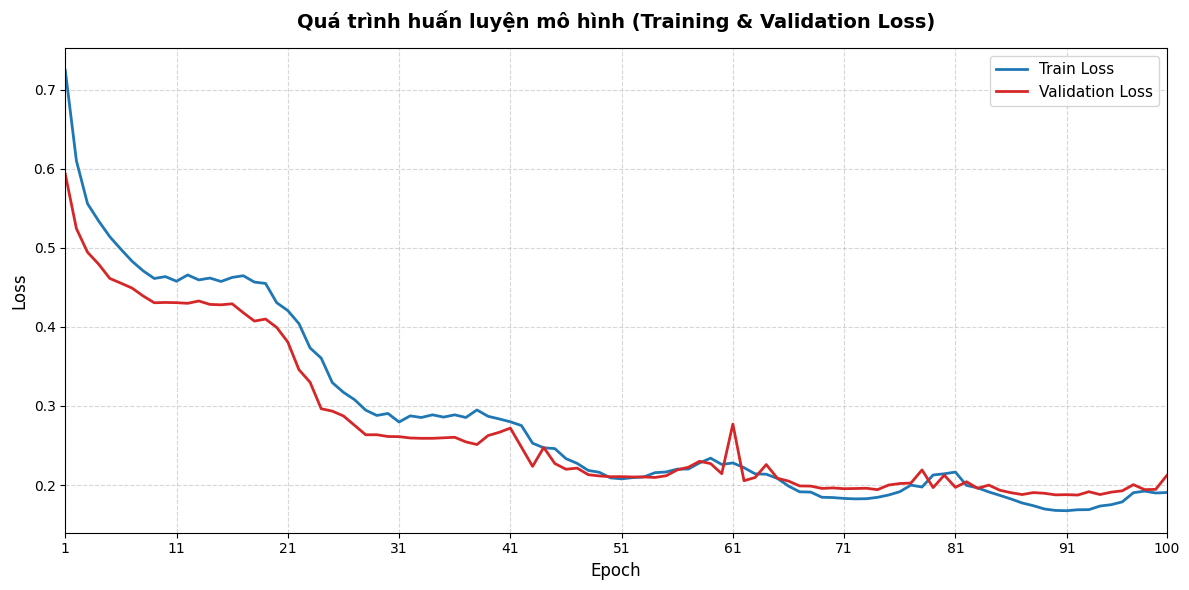

In [33]:
# --- KHỞI TẠO ĐỒ THỊ ---
plt.figure(figsize=(12, 6))

# Vẽ đường Loss
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='#d62728', linewidth=2)

# Tiêu đề và Nhãn
plt.title('Quá trình huấn luyện mô hình (Training & Validation Loss)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# --- GIẢI PHÁP TỰ ĐỘNG CĂN CHỈNH TRỤC X ---
# Giới hạn trục X chuẩn từ epoch 1 đến num_epochs
plt.xlim(1, num_epochs)

# Tự động tính toán khoảng cách (step) cho ticks dựa trên num_epochs
# Giữ cho số lượng nhãn hiển thị trên trục X luôn nằm trong khoảng từ 10 đến 20 nhãn
if num_epochs <= 20:
    step = 1
elif num_epochs <= 50:
    step = 5
elif num_epochs <= 100:
    step = 10
else:
    step = int(num_epochs / 10) # Ví dụ: 200 epochs thì step = 20, 500 epochs thì step = 50

# Tạo danh sách các điểm tick (bắt đầu từ 1, sau đó nhảy theo step, và luôn bao gồm epoch cuối cùng)
x_ticks = list(range(1, num_epochs + 1, step))
if num_epochs not in x_ticks:
    x_ticks.append(num_epochs)

plt.xticks(x_ticks)

# --- TỐI ƯU LƯỚI (GRID) VÀ CHÚ THÍCH ---
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# Tự động căn chỉnh khoảng cách lề
plt.tight_layout()

# Hiển thị đồ thị
plt.show()

# INFERENCE

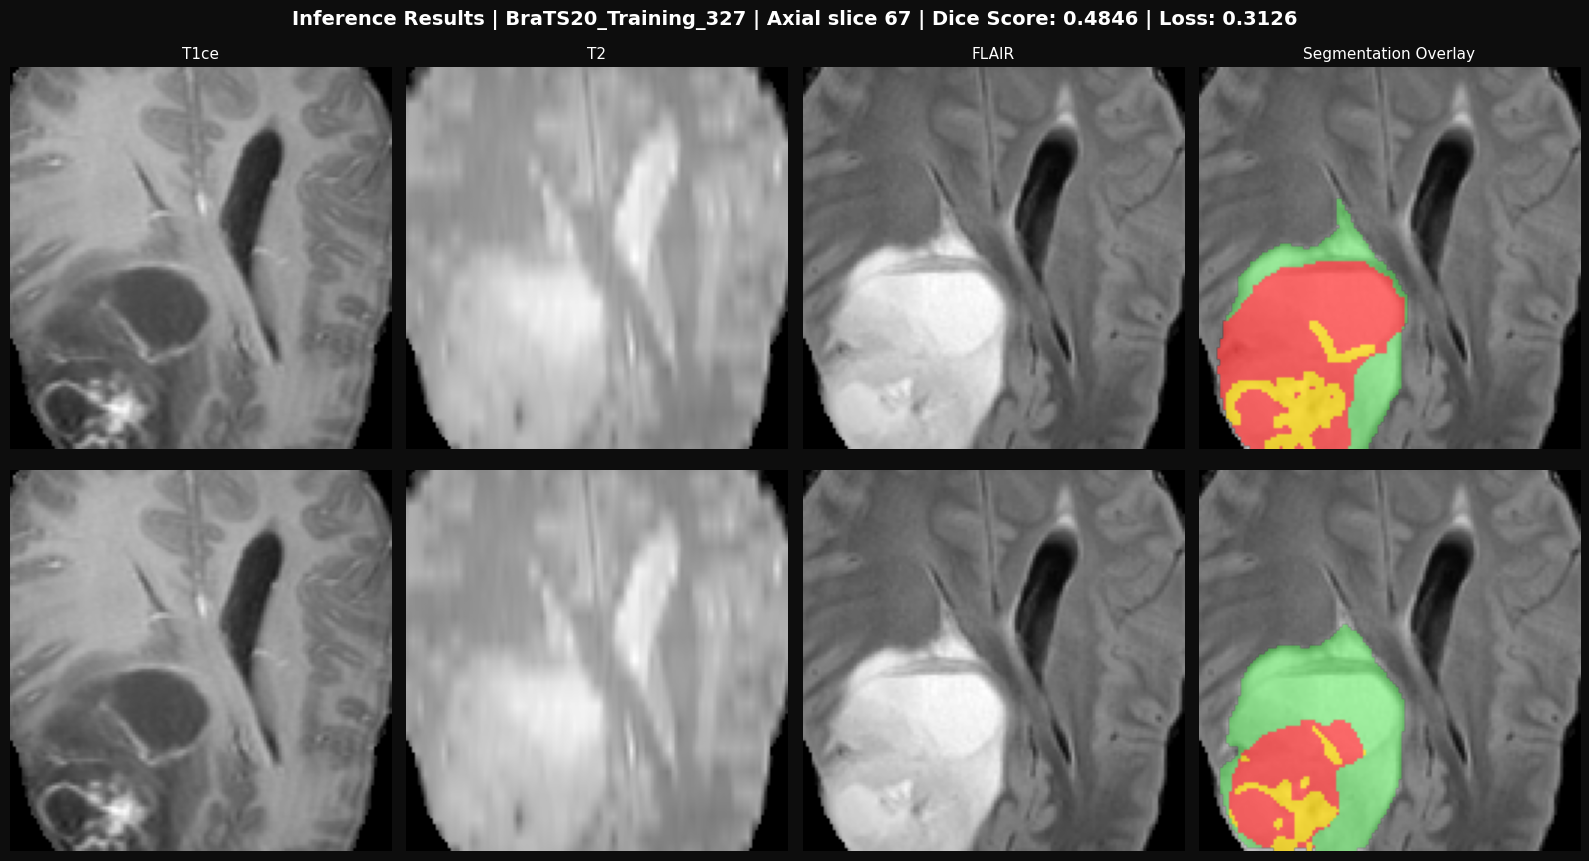

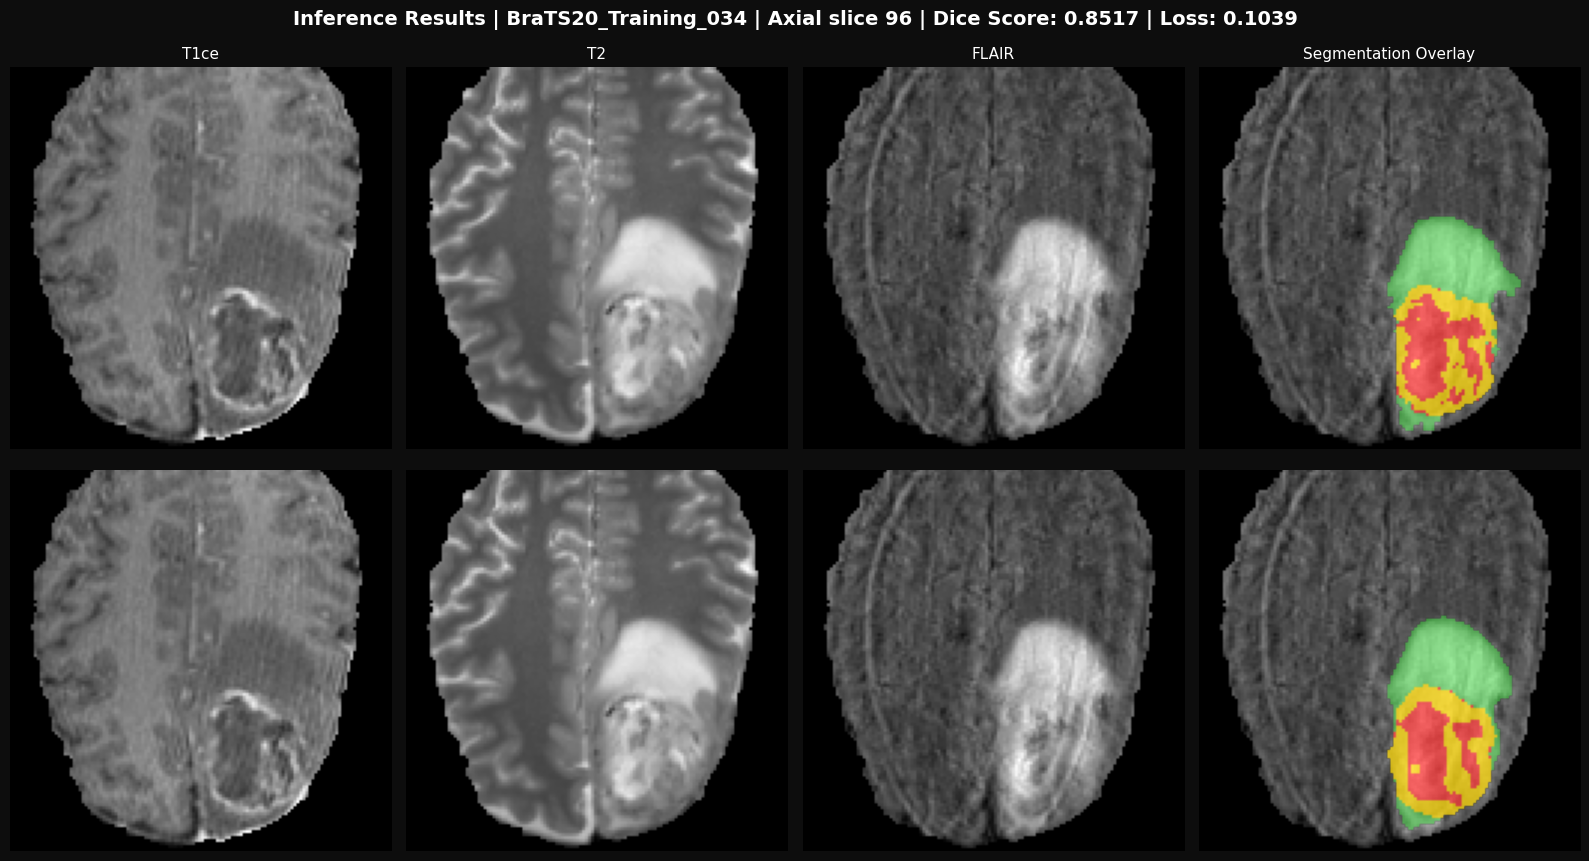

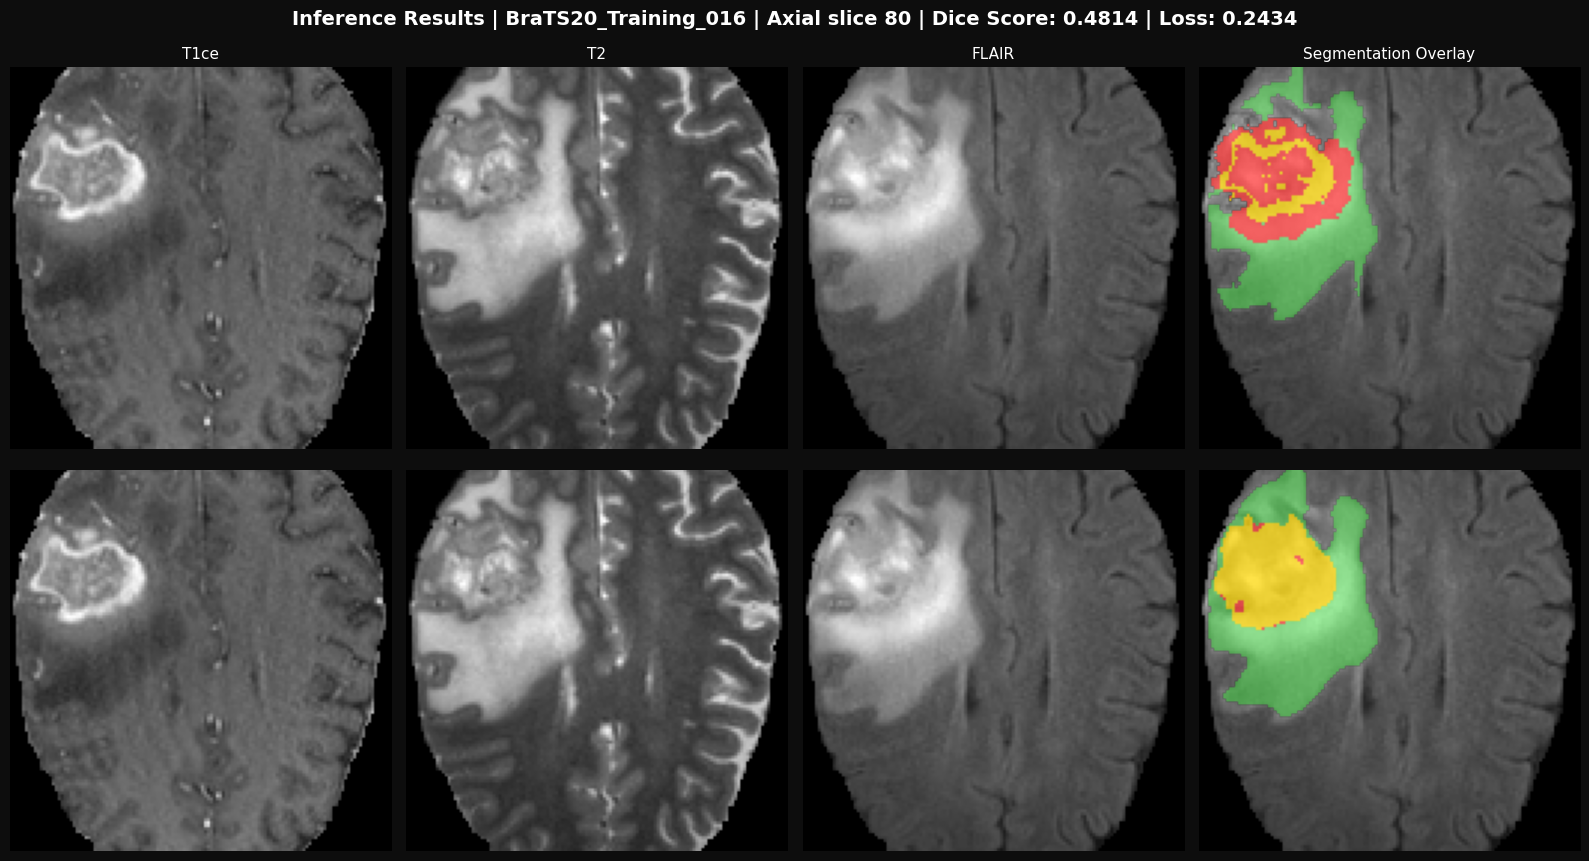

In [34]:
# Giữ nguyên cấu hình màu sắc BraTS đặc trưng của bạn
_COLOR_NCR = (1.0, 0.2,  0.2,  0.72)
_COLOR_ED  = (0.2, 0.9,  0.2,  0.45)
_COLOR_ET  = (1.0, 0.85, 0.0,  0.72)

# Map cho Ground Truth — dùng label BraTS gốc {0,1,2,4}
SEG_RGBA_GT = {1: _COLOR_NCR, 2: _COLOR_ED, 4: _COLOR_ET}

# Map cho Prediction — dùng channel index {0,1,2,3}
SEG_RGBA_PRED = {1: _COLOR_NCR, 2: _COLOR_ED, 3: _COLOR_ET}

def make_seg_rgba(seg_slice, rgba_map):
    rgba = np.zeros((*seg_slice.shape, 4), dtype=np.float32)
    for label, color in rgba_map.items():
        rgba[seg_slice == label] = color
    return rgba

def choose_tumor_slice(seg, is_gt=True):
    labels = [1, 2, 4] if is_gt else [1, 2, 3]
    tumor = np.isin(seg, labels)
    counts = tumor.sum(axis=(0, 1))
    if counts.max() == 0:
        return seg.shape[2] // 2
    return int(counts.argmax())

def calculate_dice_score(pred_np, true_np):
    """pred: {0,1,2,3} (channel index), true: {0,1,2,4} (BraTS labels)"""
    dice_per_class = []
    # Map từng channel pred → label GT tương ứng
    channel_to_gt = {1: 1, 2: 2, 3: 4}
    for pred_ch, gt_label in channel_to_gt.items():
        p_c = (pred_np == pred_ch)
        t_c = (true_np == gt_label)
        inter = np.sum(p_c & t_c)
        union = np.sum(p_c) + np.sum(t_c)
        if union == 0:
            dice_per_class.append(1.0)
        else:
            dice_per_class.append(2.0 * inter / union)
    return np.mean(dice_per_class)


def visualize_predictions_with_scores(model, dataloader, device, criterion=None, num_samples=3):
    """
    Hàm hiển thị kết quả dự đoán tái sử dụng giao diện ma trận ảnh chuyên nghiệp của BraTS.
    Hiển thị 2 hàng x 5 cột:
    - Hàng 1: Ground Truth (T1, T1ce, T2, FLAIR + True Mask Overlay)
    - Hàng 2: Model Prediction (T1, T1ce, T2, FLAIR + Predicted Mask Overlay)
    """
    model.eval()
    samples_visualized = 0
    
    # 1. Định nghĩa danh sách nhãn đầy đủ
    ALL_MODALITIES = ["T1ce", "T2", "FLAIR"]
    
    with torch.no_grad():
        for images, masks, patient_ids in dataloader:
            images_cuda = images.to(device)
            masks_cuda = masks.to(device)
            
            outputs = model(images_cuda)
            preds_cuda = torch.argmax(outputs, dim=1) 
            
            images_np = images.numpy()
            masks_np = masks.numpy()
            preds_np = preds_cuda.cpu().numpy()
            
            # 2. Lấy số lượng modalities thực tế từ hình dạng của tensor (C)
            num_modalities = images.size(1) # Lấy size của axis 1 (C)
            
            # Điều chỉnh nhãn hiển thị tương ứng với số kênh thực tế
            modalities_labels = ALL_MODALITIES[:num_modalities] if num_modalities <= 4 else [f"M{i}" for i in range(num_modalities)]
            
            for i in range(images.size(0)):
                if samples_visualized >= num_samples:
                    return
                
                patient_id = patient_ids[i]
                img_vol = images_np[i]   # (C, H, W, D)
                true_seg = masks_np[i]   # (H, W, D)
                pred_seg = preds_np[i]   # (H, W, D)
                
                # Tính toán Score (sử dụng pred_seg, true_seg dạng numpy như Cách 1 bài trước)
                dice_score = calculate_dice_score(pred_seg, true_seg)
                
                sample_loss_str = ""
                if criterion is not None:
                    sample_loss = criterion(outputs[i].unsqueeze(0), masks_cuda[i].unsqueeze(0))
                    sample_loss_str = f" | Loss: {sample_loss.item():.4f}"
                
                slice_idx = choose_tumor_slice(true_seg)
                
                # 3. Khởi tạo đồ thị với số cột = num_modalities + 1 (cột Overlay)
                num_columns = num_modalities + 1
                fig, axes = plt.subplots(2, num_columns, figsize=(4 * num_columns, 9))
                fig.patch.set_facecolor("#0d0d0d") 
                
                fig.suptitle(
                    f"Inference Results | {patient_id} | Axial slice {slice_idx} | Dice Score: {dice_score:.4f}{sample_loss_str}",
                    color="white", fontsize=14, fontweight="bold", y=0.98
                )
                
                row_labels = ["Ground Truth", "Model Prediction"]
                segs_data = [true_seg, pred_seg] 
                
                for r in range(2):
                    current_seg = segs_data[r]
                    
                    # Vẽ các cột ảnh MRI gốc dựa trên số lượng kênh thực tế
                    for c, modality_name in enumerate(modalities_labels):
                        ax = axes[r, c]
                        ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
                        
                        if r == 0:
                            ax.set_title(modality_name, color="white", fontsize=11)
                        if c == 0:
                            ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
                        ax.axis("off")
                        ax.set_facecolor("black")
                    
                    # 4. Vẽ cột cuối cùng: Overlay nhãn màu lên kênh cuối cùng sẵn có (thường là FLAIR hoặc T2)
                    ax_overlay = axes[r, num_columns - 1]
                    # Sử dụng index [num_modalities - 1] để lấy kênh cuối cùng làm nền thay vì fix cứng index 3
                    ax_overlay.imshow(img_vol[num_modalities - 1, :, :, slice_idx].T, cmap="gray", origin="lower") 
                    rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
                    ax_overlay.imshow(make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map), origin="lower")
                    
                    if r == 0:
                        ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
                    ax_overlay.axis("off")
                    ax_overlay.set_facecolor("black")
                
                plt.tight_layout()
                plt.show()
                plt.close()
                
                samples_visualized += 1

# --- CÁCH CHẠY HÀM ---
visualize_predictions_with_scores(model, val_loader, device, criterion=criterion, num_samples=3)

In [35]:
def inference(model, dataloader, device):
    model.eval()
    all_preds = []
    all_masks = []
    all_patient_ids = []

    with torch.no_grad():
        for images, masks, patient_ids in tqdm(dataloader, desc="Inference"):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # {0,1,2,3}

            # Remap channel 3 → label 4 to align with BraTS convention
            preds_brats = preds.copy()
            preds_brats[preds == 3] = 4  # {0,1,2,4}

            all_preds.append(preds_brats)
            all_masks.append(masks.cpu().numpy())
            all_patient_ids.extend(patient_ids)

    return np.concatenate(all_preds), np.concatenate(all_masks), all_patient_ids
# Run inference on validation set
predictions, true_masks, patient_ids = inference(model, val_loader, device)
print(f"Predictions shape: {predictions.shape}")
print(f"True masks shape: {true_masks.shape}")
print(f"Patient IDs: {patient_ids[:5]}")

Inference: 100%|██████████| 74/74 [00:20<00:00,  3.60it/s]


Predictions shape: (74, 128, 128, 128)
True masks shape: (74, 128, 128, 128)
Patient IDs: ['BraTS20_Training_327', 'BraTS20_Training_034', 'BraTS20_Training_016', 'BraTS20_Training_346', 'BraTS20_Training_058']


# PREDICTION

In [36]:
def predict_brats_case(model, folder_path, case_id, device, output_dir="./results"):
    model.eval()

    # Paper dùng T1ce, T2, FLAIR — KHÔNG có T1 (Section 4.1)
    modalities = ['_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    affine = None
    original_shape = None

    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        if affine is None:
            affine = nii_img.affine
            original_shape = nii_img.shape  # Lưu lại kích thước gốc (H, W, D) để khôi phục sau này
        img_data = nii_img.get_fdata()

        # Dùng Min-Max [0,1] — đúng với BraTSDataset3D
        vmin, vmax = img_data.min(), img_data.max()
        if vmax > vmin:
            img_data = (img_data - vmin) / (vmax - vmin)
        else:
            img_data = np.zeros_like(img_data)
            
        volume_list.append(img_data)

    # ── THAY THẾ ND_ZOOM BẰNG CROP_OR_PAD_3D ──
    # Xử lý cắt lấy tâm hoặc đệm thêm cạnh độc lập trên từng modality về chuẩn 128x128x128
    processed_volumes = [crop_or_pad_3d(vol, target_shape=(128, 128, 128)) for vol in volume_list]
    
    # Stack các kênh lại với nhau -> Shape hoàn chỉnh: (Ch=3, H=128, W=128, D=128)
    image_data = np.stack(processed_volumes, axis=0)

    # Chuyển đổi tensor và đưa lên thiết bị tính toán (GPU/CPU)
    image_tensor = torch.from_numpy(image_data).float().unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)          # (1, 4, 128, 128, 128)
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()  # (128, 128, 128), giá trị nhãn: {0,1,2,3}

    # Map kênh 3 → nhãn 4 theo đúng quy ước cấu trúc dữ liệu của giải đấu BraTS
    preds_brats = preds.copy()
    preds_brats[preds == 3] = 4

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"pred_{case_id}.nii")
    
    # ── ĐẢO NGƯỢC QUY TRÌNH: ĐƯA MASK 128³ VỀ LẠI KÍCH THƯỚC GỐC ──
    # Thay vì dùng nd_zoom làm biến dạng biên khối u, ta dùng chính hàm crop_or_pad_3d 
    # để dán (paste) vùng dự đoán về lại đúng tọa độ không gian ban đầu của bệnh nhân.
    full_pred = crop_or_pad_3d(preds_brats, target_shape=original_shape)
    full_pred = full_pred.astype(np.uint8)
    
    # Lưu file NIfTI
    nib.save(nib.Nifti1Image(full_pred, affine), output_path)

    print(f"✅ Saved: {output_path} | Input 128³ processed via Center Crop/Pad.")
    return full_pred  # Trả về mảng {0,1,2,3} kích thước 128³ hỗ trợ trực quan hóa trực tiếp

In [37]:
def visualize_single_prediction(folder_path, case_id, pred_mask, true_mask_path=None):
    """
    Hàm hiển thị kết quả dự đoán cho một ca bệnh đơn lẻ từ đường dẫn file .nii.
    
    Args:
        folder_path (str): Thư mục chứa ca bệnh (để load lại các ảnh MRI gốc).
        case_id (str): Tên ca bệnh.
        pred_mask (np.ndarray): Mảng mask dự đoán dạng NumPy (H, W, D) thu được từ mô hình.
        true_mask_path (str, optional): Đường dẫn tới file nhãn thật nếu có (ví dụ file _seg.nii).
                                       Nếu không truyền, hàm chỉ vẽ phần ảnh gốc và kết quả mô hình tìm được.
    """
    MODALITIES_LABELS = ["T1", "T1ce", "T2", "FLAIR"]
    modalities = ['_t1.nii', '_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # 1. Load lại ảnh gốc (dùng để hiển thị làm nền)
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        volume_list.append(nii_img.get_fdata())
    
    img_vol = np.stack(volume_list, axis=0) # Shape: (4, H, W, D)
    
    # 2. Kiểm tra xem có nhãn Ground Truth (True Mask) để so sánh hay không
    has_true_mask = False
    true_seg = None
    dice_score_str = ""
    
    if true_mask_path and os.path.exists(true_mask_path):
        true_seg = nib.load(true_mask_path).get_fdata() # (H, W, D)
        has_true_mask = True
        
        # Tính toán nhanh Dice Score (NumPy version)
        _pred_to_gt = {1: 1, 2: 2, 3: 4}
        dice_list = []
        for pred_ch, gt_label in _pred_to_gt.items():
            p_c = (pred_mask == pred_ch)
            t_c = (true_seg == gt_label)
            intersection = np.sum(p_c & t_c)
            union = np.sum(p_c) + np.sum(t_c)
            if union > 0:
                dice_list.append((2.0 * intersection) / union)
        if dice_list:
            dice_score_str = f" | Dice Score: {np.mean(dice_list):.4f}"
            
    # Tự động chọn lát cắt chứa nhiều u nhất (ưu tiên tìm trên true mask, nếu không có thì tìm trên pred mask)
    if has_true_mask:
        slice_idx = choose_tumor_slice(true_seg, is_gt=True)
    else:
        slice_idx = choose_tumor_slice(pred_mask, is_gt=False)
    
    # 3. ĐIỀU CHỈNH SỐ HÀNG ĐỒ THỊ (2 hàng nếu có nhãn thật, 1 hàng nếu chỉ có dự đoán)
    num_rows = 2 if has_true_mask else 1
    fig, axes = plt.subplots(num_rows, 5, figsize=(22, 5 * num_rows))
    fig.patch.set_facecolor("#0d0d0d")
    
    # Đảm bảo axes luôn là mảng 2 chiều kể cả khi chỉ có 1 hàng để tránh lỗi chỉ mục
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    fig.suptitle(
        f"Single Case Evaluation | {case_id} | Axial slice {slice_idx}{dice_score_str}",
        color="white", fontsize=14, fontweight="bold", y=0.98
    )
    
    row_labels = ["Ground Truth", "Model Prediction"] if has_true_mask else ["Model Prediction"]
    segs_data = [true_seg, pred_mask] if has_true_mask else [pred_mask]
    
    for r in range(num_rows):
        current_seg = segs_data[r]
        
        # Vẽ 4 cột ảnh MRI gốc (T1, T1ce, T2, FLAIR)
        for c, modality_name in enumerate(MODALITIES_LABELS):
            ax = axes[r, c]
            ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
            if r == 0:
                ax.set_title(modality_name, color="white", fontsize=11)
            if c == 0:
                ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
            ax.axis("off")
            ax.set_facecolor("black")
        
        # Vẽ cột thứ 5: Overlay nhãn màu lên ảnh xung FLAIR
        ax_overlay = axes[r, 4]
        flair_slice = img_vol[3, :, :, slice_idx].T   # shape (W, H) — rows=W, cols=H

        # Lấy lát cắt mask hiện tại (kích thước 128x128)
        mask_slice = current_seg[:, :, slice_idx].T 
        
        # Nếu kích thước mask khác kích thước ảnh FLAIR, tiến hành resize mask
        if mask_slice.shape != flair_slice.shape:
            from scipy.ndimage import zoom
            zoom_factors = (flair_slice.shape[0] / mask_slice.shape[0], flair_slice.shape[1] / mask_slice.shape[1])
            # Dùng order=0 để giữ nguyên giá trị nhãn (vùng phân vùng không bị mờ nhòe)
            mask_slice = zoom(mask_slice, zoom_factors, order=0)

        rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
        seg_slice = make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map)

        # flair_slice.shape = (rows, cols) = (W_orig, H_orig)
        rows, cols = flair_slice.shape
        ext = [0, cols, 0, rows]   # [x_min, x_max, y_min, y_max] = [0, H_orig, 0, W_orig]

        ax_overlay.imshow(flair_slice, cmap="gray", origin="lower", extent=ext)
        ax_overlay.imshow(seg_slice, origin="lower", extent=ext)
        if r == 0:
            ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
        ax_overlay.axis("off")
        ax_overlay.set_facecolor("black")
        
    plt.tight_layout()
    plt.show()
    plt.close()

Đang chạy dự đoán cho ca bệnh: BraTS20_Validation_010
✅ Saved: ./results\pred_BraTS20_Validation_010.nii | Input 128³ processed via Center Crop/Pad.
Predicted mask shape: (240, 240, 155) | Unique values: [0 1 2 4]
Đang hiển thị kết quả dự đoán...


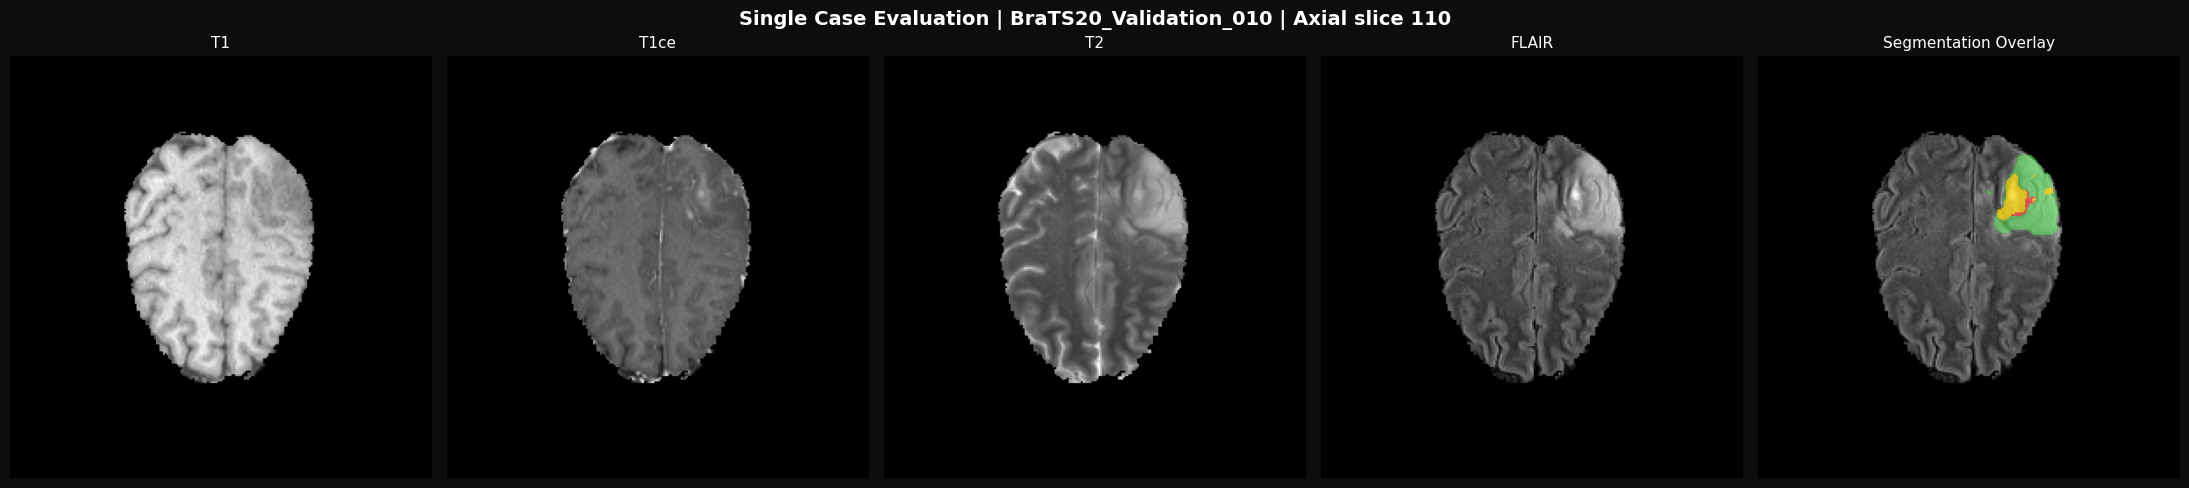

In [38]:
case_folder = "BraTS2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_010"
case_name = "BraTS20_Validation_010"
print(f"Đang chạy dự đoán cho ca bệnh: {case_name}")
pred_mask = predict_brats_case(model, case_folder, case_name, device, output_dir="./results")
print(f"Predicted mask shape: {pred_mask.shape} | Unique values: {np.unique(pred_mask)}")
print("Đang hiển thị kết quả dự đoán...")
visualize_single_prediction(
    folder_path=case_folder, 
    case_id=case_name, 
    pred_mask=pred_mask
)

# LOAD PRE-TRAINED

In [40]:
import torch

# CHỈNH SỬA Ở ĐÂY: Truyền tham số để cấu hình đầu ra là 4 lớp cho khớp với checkpoint
# Tùy thuộc vào cách bạn viết class LATUPNet, tên tham số có thể là num_classes, out_channels hoặc classes.
# Thông thường phổ biến nhất là num_classes hoặc out_channels.
try:
    model = LATUPNet(num_classes=4) 
except TypeError:
    try:
        model = LATUPNet(out_channels=4)
    except TypeError:
        # Nếu class LATUPNet không nhận tham số, bạn cần mở file định nghĩa mô hình (ví dụ: models.py)
        # Tìm đến lớp self.final_conv và sửa số 3 thành số 4 thủ công.
        model = LATUPNet() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")
model_path = 'best_latupnet_seed.pth' 

state_dict = torch.load(model_path, map_location=device)

if 'model_state_dict' in state_dict:
    state_dict = state_dict['model_state_dict']

# Nạp trọng số - Bây giờ kích thước đã khớp hoàn toàn [4, 32, 1, 1, 1]
model.load_state_dict(state_dict)
model.to(device)

model.eval()
print("Đã load mô hình LATUPNet thành công!")

Đang sử dụng thiết bị: cuda
Đã load mô hình LATUPNet thành công!


In [41]:
# Giữ nguyên cấu hình màu sắc BraTS đặc trưng của bạn
_COLOR_NCR = (1.0, 0.2,  0.2,  0.72)
_COLOR_ED  = (0.2, 0.9,  0.2,  0.45)
_COLOR_ET  = (1.0, 0.85, 0.0,  0.72)

# Map cho Ground Truth — dùng label BraTS gốc {0,1,2,4}
SEG_RGBA_GT = {1: _COLOR_NCR, 2: _COLOR_ED, 4: _COLOR_ET}

# Map cho Prediction — dùng channel index {0,1,2,3}
SEG_RGBA_PRED = {1: _COLOR_NCR, 2: _COLOR_ED, 3: _COLOR_ET}

def make_seg_rgba(seg_slice, rgba_map):
    rgba = np.zeros((*seg_slice.shape, 4), dtype=np.float32)
    for label, color in rgba_map.items():
        rgba[seg_slice == label] = color
    return rgba

def choose_tumor_slice(seg, is_gt=True):
    labels = [1, 2, 4] if is_gt else [1, 2, 3]
    tumor = np.isin(seg, labels)
    counts = tumor.sum(axis=(0, 1))
    if counts.max() == 0:
        return seg.shape[2] // 2
    return int(counts.argmax())

def calculate_dice_score(pred_np, true_np):
    """pred: {0,1,2,3} (channel index), true: {0,1,2,4} (BraTS labels)"""
    dice_per_class = []
    # Map từng channel pred → label GT tương ứng
    channel_to_gt = {1: 1, 2: 2, 3: 4}
    for pred_ch, gt_label in channel_to_gt.items():
        p_c = (pred_np == pred_ch)
        t_c = (true_np == gt_label)
        inter = np.sum(p_c & t_c)
        union = np.sum(p_c) + np.sum(t_c)
        if union == 0:
            dice_per_class.append(1.0)
        else:
            dice_per_class.append(2.0 * inter / union)
    return np.mean(dice_per_class)


def visualize_predictions_with_scores(model, dataloader, device, criterion=None, num_samples=3):
    """
    Hàm hiển thị kết quả dự đoán tái sử dụng giao diện ma trận ảnh chuyên nghiệp của BraTS.
    Hiển thị 2 hàng x 5 cột:
    - Hàng 1: Ground Truth (T1, T1ce, T2, FLAIR + True Mask Overlay)
    - Hàng 2: Model Prediction (T1, T1ce, T2, FLAIR + Predicted Mask Overlay)
    """
    model.eval()
    samples_visualized = 0
    
    # 1. Định nghĩa danh sách nhãn đầy đủ
    ALL_MODALITIES = ["T1ce", "T2", "FLAIR"]
    
    with torch.no_grad():
        for images, masks, patient_ids in dataloader:
            images_cuda = images.to(device)
            masks_cuda = masks.to(device)
            
            outputs = model(images_cuda)
            preds_cuda = torch.argmax(outputs, dim=1) 
            
            images_np = images.numpy()
            masks_np = masks.numpy()
            preds_np = preds_cuda.cpu().numpy()
            
            # 2. Lấy số lượng modalities thực tế từ hình dạng của tensor (C)
            num_modalities = images.size(1) # Lấy size của axis 1 (C)
            
            # Điều chỉnh nhãn hiển thị tương ứng với số kênh thực tế
            modalities_labels = ALL_MODALITIES[:num_modalities] if num_modalities <= 4 else [f"M{i}" for i in range(num_modalities)]
            
            for i in range(images.size(0)):
                if samples_visualized >= num_samples:
                    return
                
                patient_id = patient_ids[i]
                img_vol = images_np[i]   # (C, H, W, D)
                true_seg = masks_np[i]   # (H, W, D)
                pred_seg = preds_np[i]   # (H, W, D)
                
                # Tính toán Score (sử dụng pred_seg, true_seg dạng numpy như Cách 1 bài trước)
                dice_score = calculate_dice_score(pred_seg, true_seg)
                
                sample_loss_str = ""
                if criterion is not None:
                    sample_loss = criterion(outputs[i].unsqueeze(0), masks_cuda[i].unsqueeze(0))
                    sample_loss_str = f" | Loss: {sample_loss.item():.4f}"
                
                slice_idx = choose_tumor_slice(true_seg)
                
                # 3. Khởi tạo đồ thị với số cột = num_modalities + 1 (cột Overlay)
                num_columns = num_modalities + 1
                fig, axes = plt.subplots(2, num_columns, figsize=(4 * num_columns, 9))
                fig.patch.set_facecolor("#0d0d0d") 
                
                fig.suptitle(
                    f"Inference Results | {patient_id} | Axial slice {slice_idx} | Dice Score: {dice_score:.4f}{sample_loss_str}",
                    color="white", fontsize=14, fontweight="bold", y=0.98
                )
                
                row_labels = ["Ground Truth", "Model Prediction"]
                segs_data = [true_seg, pred_seg] 
                
                for r in range(2):
                    current_seg = segs_data[r]
                    
                    # Vẽ các cột ảnh MRI gốc dựa trên số lượng kênh thực tế
                    for c, modality_name in enumerate(modalities_labels):
                        ax = axes[r, c]
                        ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
                        
                        if r == 0:
                            ax.set_title(modality_name, color="white", fontsize=11)
                        if c == 0:
                            ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
                        ax.axis("off")
                        ax.set_facecolor("black")
                    
                    # 4. Vẽ cột cuối cùng: Overlay nhãn màu lên kênh cuối cùng sẵn có (thường là FLAIR hoặc T2)
                    ax_overlay = axes[r, num_columns - 1]
                    # Sử dụng index [num_modalities - 1] để lấy kênh cuối cùng làm nền thay vì fix cứng index 3
                    ax_overlay.imshow(img_vol[num_modalities - 1, :, :, slice_idx].T, cmap="gray", origin="lower") 
                    rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
                    ax_overlay.imshow(make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map), origin="lower")
                    
                    if r == 0:
                        ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
                    ax_overlay.axis("off")
                    ax_overlay.set_facecolor("black")
                
                plt.tight_layout()
                plt.show()
                plt.close()
                
                samples_visualized += 1

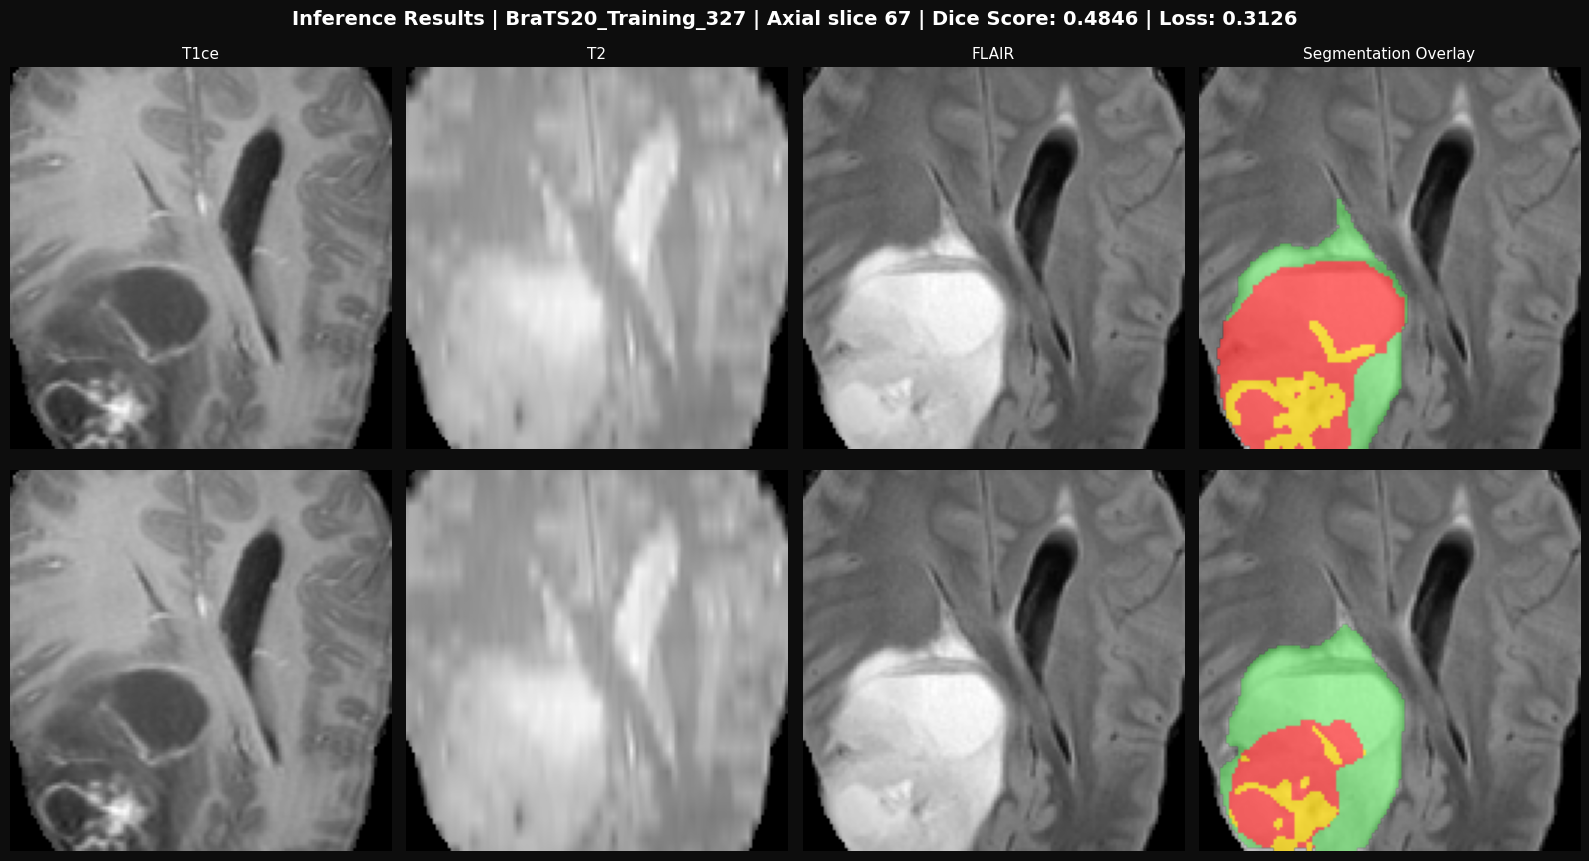

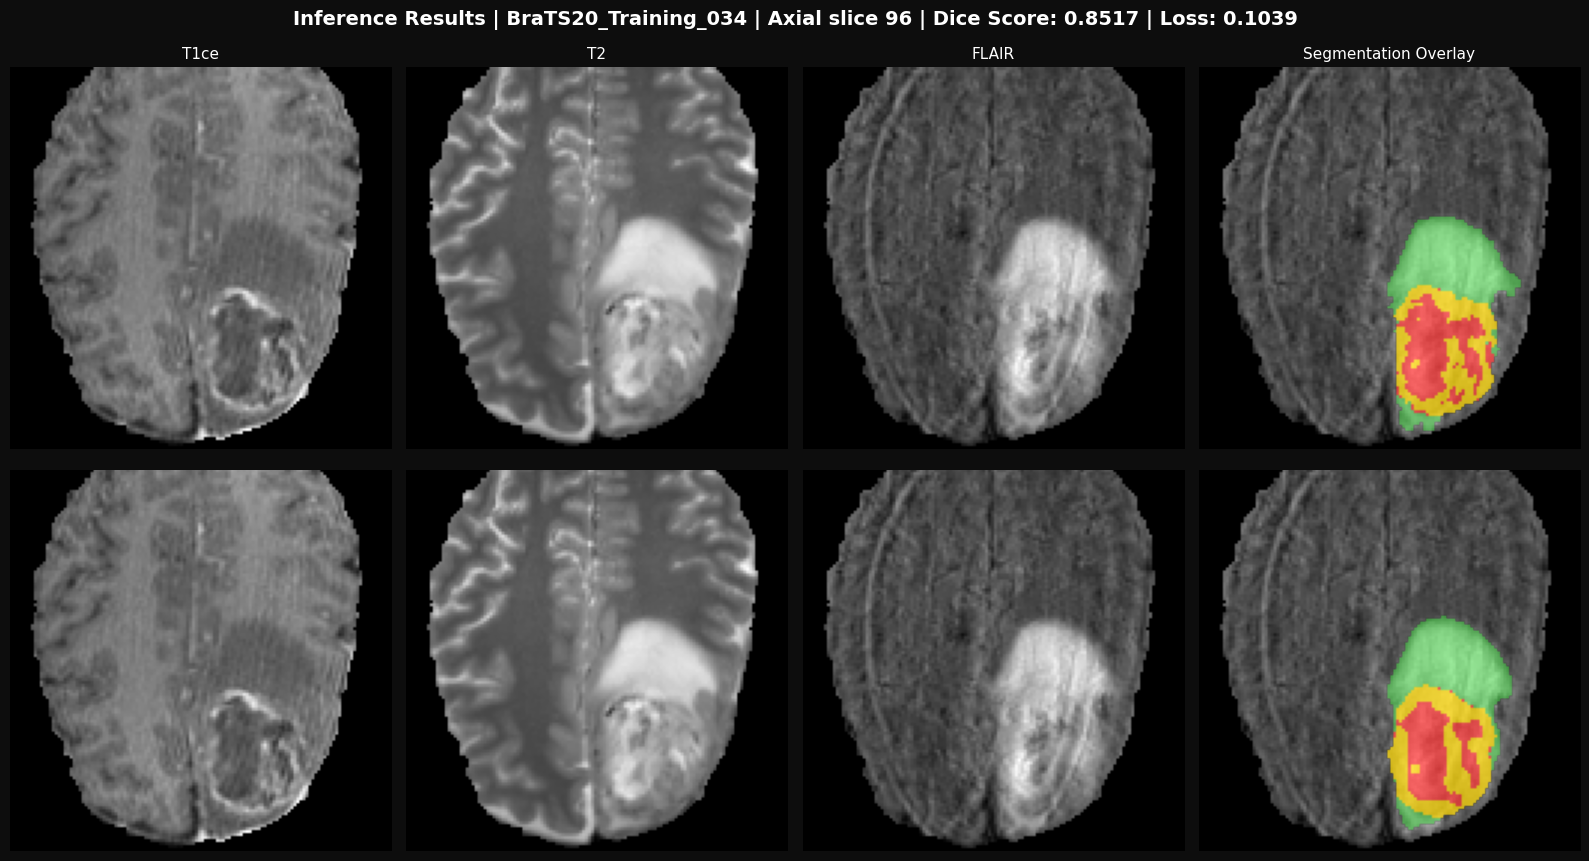

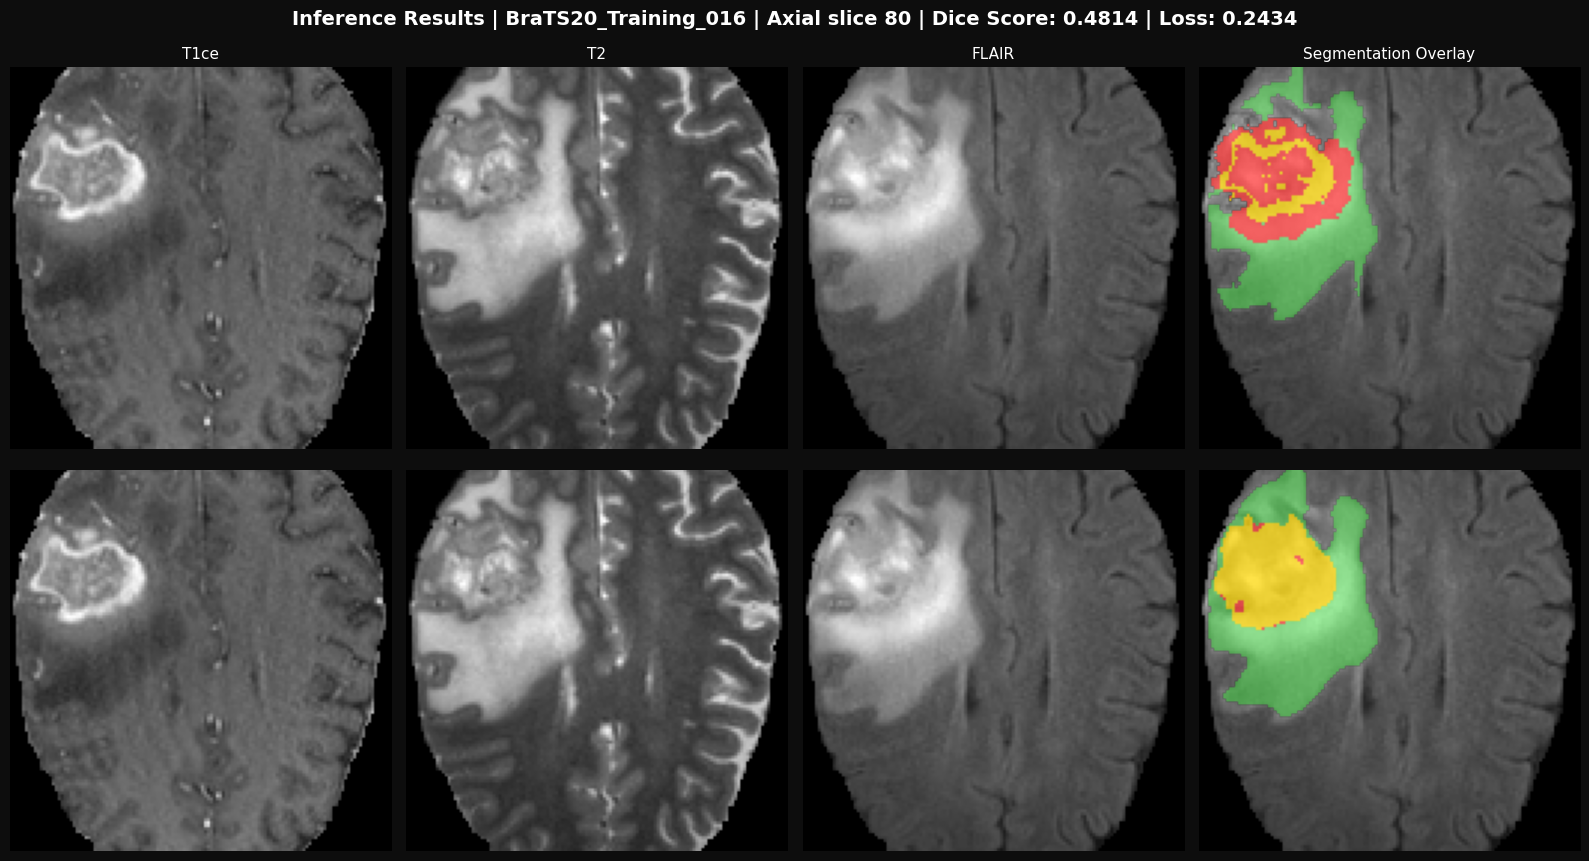

In [42]:
visualize_predictions_with_scores(model, val_loader, device, criterion=criterion, num_samples=3)

In [43]:
def predict_brats_case(model, folder_path, case_id, device, output_dir="./results"):
    model.eval()

    # Paper dùng T1ce, T2, FLAIR — KHÔNG có T1 (Section 4.1)
    modalities = ['_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    affine = None
    original_shape = None

    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        if affine is None:
            affine = nii_img.affine
            original_shape = nii_img.shape  # Lưu lại kích thước gốc (H, W, D) để khôi phục sau này
        img_data = nii_img.get_fdata()

        # Dùng Min-Max [0,1] — đúng với BraTSDataset3D
        vmin, vmax = img_data.min(), img_data.max()
        if vmax > vmin:
            img_data = (img_data - vmin) / (vmax - vmin)
        else:
            img_data = np.zeros_like(img_data)
            
        volume_list.append(img_data)

    # ── THAY THẾ ND_ZOOM BẰNG CROP_OR_PAD_3D ──
    # Xử lý cắt lấy tâm hoặc đệm thêm cạnh độc lập trên từng modality về chuẩn 128x128x128
    processed_volumes = [crop_or_pad_3d(vol, target_shape=(128, 128, 128)) for vol in volume_list]
    
    # Stack các kênh lại với nhau -> Shape hoàn chỉnh: (Ch=3, H=128, W=128, D=128)
    image_data = np.stack(processed_volumes, axis=0)

    # Chuyển đổi tensor và đưa lên thiết bị tính toán (GPU/CPU)
    image_tensor = torch.from_numpy(image_data).float().unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)          # (1, 4, 128, 128, 128)
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()  # (128, 128, 128), giá trị nhãn: {0,1,2,3}

    # Map kênh 3 → nhãn 4 theo đúng quy ước cấu trúc dữ liệu của giải đấu BraTS
    preds_brats = preds.copy()
    preds_brats[preds == 3] = 4

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"pred_{case_id}.nii")
    
    # ── ĐẢO NGƯỢC QUY TRÌNH: ĐƯA MASK 128³ VỀ LẠI KÍCH THƯỚC GỐC ──
    # Thay vì dùng nd_zoom làm biến dạng biên khối u, ta dùng chính hàm crop_or_pad_3d 
    # để dán (paste) vùng dự đoán về lại đúng tọa độ không gian ban đầu của bệnh nhân.
    full_pred = crop_or_pad_3d(preds_brats, target_shape=original_shape)
    full_pred = full_pred.astype(np.uint8)
    
    # Lưu file NIfTI
    nib.save(nib.Nifti1Image(full_pred, affine), output_path)

    print(f"✅ Saved: {output_path} | Input 128³ processed via Center Crop/Pad.")
    return full_pred  # Trả về mảng {0,1,2,3} kích thước 128³ hỗ trợ trực quan hóa trực tiếp

def visualize_single_prediction(folder_path, case_id, pred_mask, true_mask_path=None):
    """
    Hàm hiển thị kết quả dự đoán cho một ca bệnh đơn lẻ từ đường dẫn file .nii.
    
    Args:
        folder_path (str): Thư mục chứa ca bệnh (để load lại các ảnh MRI gốc).
        case_id (str): Tên ca bệnh.
        pred_mask (np.ndarray): Mảng mask dự đoán dạng NumPy (H, W, D) thu được từ mô hình.
        true_mask_path (str, optional): Đường dẫn tới file nhãn thật nếu có (ví dụ file _seg.nii).
                                       Nếu không truyền, hàm chỉ vẽ phần ảnh gốc và kết quả mô hình tìm được.
    """
    MODALITIES_LABELS = ["T1", "T1ce", "T2", "FLAIR"]
    modalities = ['_t1.nii', '_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # 1. Load lại ảnh gốc (dùng để hiển thị làm nền)
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        volume_list.append(nii_img.get_fdata())
    
    img_vol = np.stack(volume_list, axis=0) # Shape: (4, H, W, D)
    
    # 2. Kiểm tra xem có nhãn Ground Truth (True Mask) để so sánh hay không
    has_true_mask = False
    true_seg = None
    dice_score_str = ""
    
    if true_mask_path and os.path.exists(true_mask_path):
        true_seg = nib.load(true_mask_path).get_fdata() # (H, W, D)
        has_true_mask = True
        
        # Tính toán nhanh Dice Score (NumPy version)
        _pred_to_gt = {1: 1, 2: 2, 3: 4}
        dice_list = []
        for pred_ch, gt_label in _pred_to_gt.items():
            p_c = (pred_mask == pred_ch)
            t_c = (true_seg == gt_label)
            intersection = np.sum(p_c & t_c)
            union = np.sum(p_c) + np.sum(t_c)
            if union > 0:
                dice_list.append((2.0 * intersection) / union)
        if dice_list:
            dice_score_str = f" | Dice Score: {np.mean(dice_list):.4f}"
            
    # Tự động chọn lát cắt chứa nhiều u nhất (ưu tiên tìm trên true mask, nếu không có thì tìm trên pred mask)
    if has_true_mask:
        slice_idx = choose_tumor_slice(true_seg, is_gt=True)
    else:
        slice_idx = choose_tumor_slice(pred_mask, is_gt=False)
    
    # 3. ĐIỀU CHỈNH SỐ HÀNG ĐỒ THỊ (2 hàng nếu có nhãn thật, 1 hàng nếu chỉ có dự đoán)
    num_rows = 2 if has_true_mask else 1
    fig, axes = plt.subplots(num_rows, 5, figsize=(22, 5 * num_rows))
    fig.patch.set_facecolor("#0d0d0d")
    
    # Đảm bảo axes luôn là mảng 2 chiều kể cả khi chỉ có 1 hàng để tránh lỗi chỉ mục
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    fig.suptitle(
        f"Single Case Evaluation | {case_id} | Axial slice {slice_idx}{dice_score_str}",
        color="white", fontsize=14, fontweight="bold", y=0.98
    )
    
    row_labels = ["Ground Truth", "Model Prediction"] if has_true_mask else ["Model Prediction"]
    segs_data = [true_seg, pred_mask] if has_true_mask else [pred_mask]
    
    for r in range(num_rows):
        current_seg = segs_data[r]
        
        # Vẽ 4 cột ảnh MRI gốc (T1, T1ce, T2, FLAIR)
        for c, modality_name in enumerate(MODALITIES_LABELS):
            ax = axes[r, c]
            ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
            if r == 0:
                ax.set_title(modality_name, color="white", fontsize=11)
            if c == 0:
                ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
            ax.axis("off")
            ax.set_facecolor("black")
        
        # Vẽ cột thứ 5: Overlay nhãn màu lên ảnh xung FLAIR
        ax_overlay = axes[r, 4]
        flair_slice = img_vol[3, :, :, slice_idx].T   # shape (W, H) — rows=W, cols=H

        # Lấy lát cắt mask hiện tại (kích thước 128x128)
        mask_slice = current_seg[:, :, slice_idx].T 
        
        # Nếu kích thước mask khác kích thước ảnh FLAIR, tiến hành resize mask
        if mask_slice.shape != flair_slice.shape:
            from scipy.ndimage import zoom
            zoom_factors = (flair_slice.shape[0] / mask_slice.shape[0], flair_slice.shape[1] / mask_slice.shape[1])
            # Dùng order=0 để giữ nguyên giá trị nhãn (vùng phân vùng không bị mờ nhòe)
            mask_slice = zoom(mask_slice, zoom_factors, order=0)

        rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
        seg_slice = make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map)

        # flair_slice.shape = (rows, cols) = (W_orig, H_orig)
        rows, cols = flair_slice.shape
        ext = [0, cols, 0, rows]   # [x_min, x_max, y_min, y_max] = [0, H_orig, 0, W_orig]

        ax_overlay.imshow(flair_slice, cmap="gray", origin="lower", extent=ext)
        ax_overlay.imshow(seg_slice, origin="lower", extent=ext)
        if r == 0:
            ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
        ax_overlay.axis("off")
        ax_overlay.set_facecolor("black")
        
    plt.tight_layout()
    plt.show()
    plt.close()

Đang chạy dự đoán cho ca bệnh: BraTS20_Validation_049
✅ Saved: ./results\pred_BraTS20_Validation_049.nii | Input 128³ processed via Center Crop/Pad.
Predicted mask shape: (240, 240, 155) | Unique values: [0 1 2 4]
Đang hiển thị kết quả dự đoán...


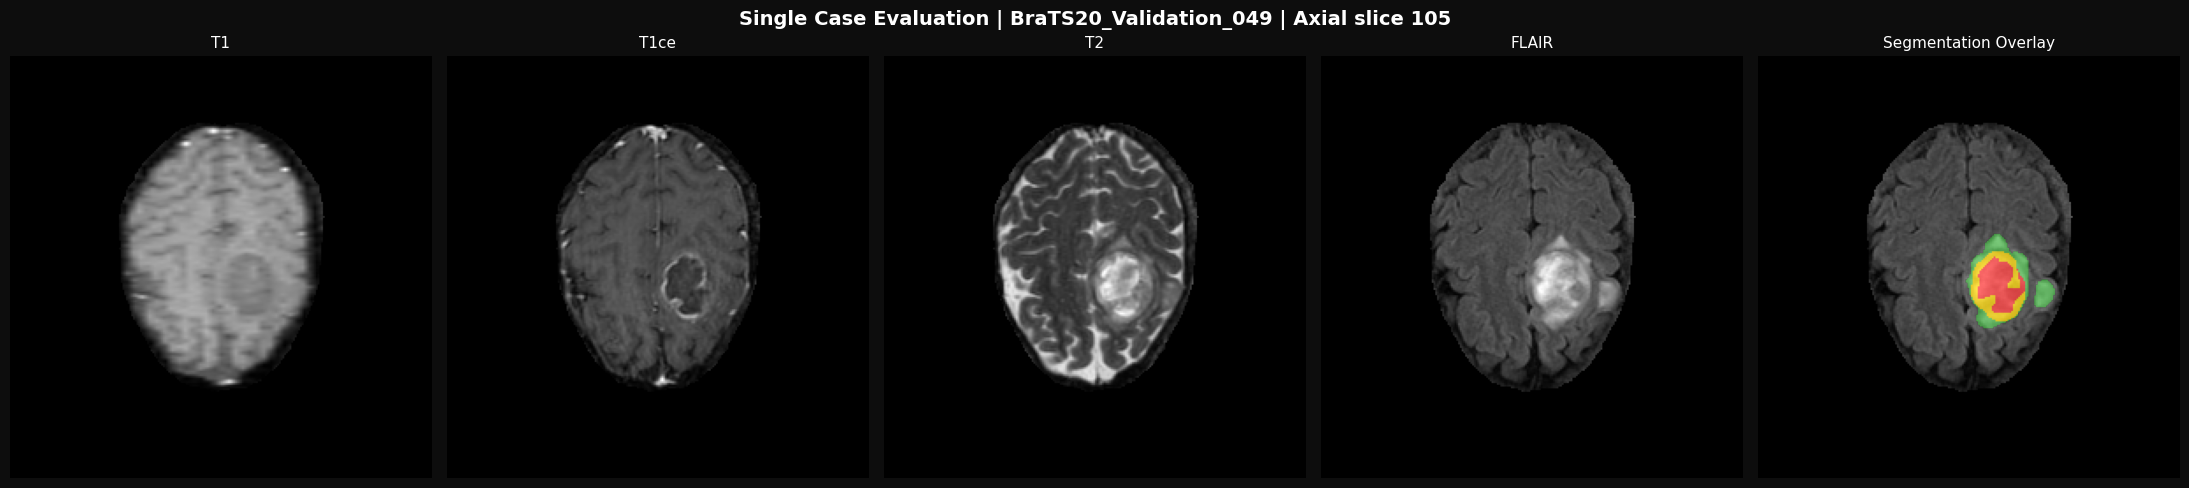

In [44]:
case_folder = "BraTS2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_049"
case_name = "BraTS20_Validation_049"
print(f"Đang chạy dự đoán cho ca bệnh: {case_name}")
pred_mask = predict_brats_case(model, case_folder, case_name, device, output_dir="./results")
print(f"Predicted mask shape: {pred_mask.shape} | Unique values: {np.unique(pred_mask)}")
print("Đang hiển thị kết quả dự đoán...")
visualize_single_prediction(
    folder_path=case_folder, 
    case_id=case_name, 
    pred_mask=pred_mask
)